# Technical Support AI Agent: A RAG-based Implementation

**Domain:** automated Level-1 Technical Support (corporate IT Service Desk)
**Architecture:** Retrieval-Augmented Generation (RAG)
**Stack:** Python · LangChain · FAISS · OpenAI API · scikit-learn · Matplotlib

---

## 1. Project Title and Introduction

A general-purpose Large Language Model is an excellent writer but a poor
librarian for *private* corporate knowledge. In a technical-support setting it
suffers from three structural problems:

| Problem | Consequence for a help-desk agent |
|---|---|
| **Knowledge cutoff** | It does not know the procedure or error code published last week. |
| **No access to private data** | It has never seen the internal knowledge base or the asset register. |
| **Hallucination** | It invents plausible-but-wrong menu paths, error codes and SLAs. |

**Retrieval-Augmented Generation (RAG)** addresses all three *without retraining
the model*: the relevant paragraphs of the official documentation are retrieved
at query time and inserted into the model's context, so every answer is
*grounded* in verifiable source text.

This notebook implements a complete and runnable support agent on top of the
Northwind IT Service Desk knowledge base (`tech_support.txt`). The agent:

1. answers **only** from the retrieved documentation;
2. **abstains** and escalates when the documentation does not cover the question;
3. **cites** the source section it used;
4. talks to **any OpenAI-compatible endpoint** — the API key, the base URL and
   both model names are read from a `.env` file, so the agent runs against
   OpenAI itself, an Azure-style gateway, or any third-party compatible relay
   without a single code change.

### Notebook outline

| § | Section | Content |
|---|---|---|
| 2 | Theoretical background | LLMs, RAG, embeddings, RAG vs fine-tuning |
| 3 | Configuration | `.env` loading, endpoint preflight, capability report |
| 4 | Data preparation | knowledge base, corpus EDA |
| 5 | Text splitting | 500-character recursive chunking |
| 6 | Vector embeddings | remote API or local model, one interface |
| 7 | Vector store | FAISS inner-product index + persistence |
| 8 | Retrieval | semantic similarity search, sanity check |
| 9 | Agent logic | prompt, LLM, LCEL chain, guardrails |
| 10 | Usage and testing | in-domain and out-of-domain cases |
| 11 | Evaluation | Hit@k, MRR, embedding-space visualisation |
| 12 | Embedder fine-tuning | contrastive training on CPU, before/after metrics |

> **Requires an API key.** Generation is always a real network call, and there is
> no offline fallback for it. Embeddings can additionally be served by a local
> model (`EMBED_BACKEND=local`), but that changes *where the vectors come from*,
> not whether credentials are needed. Section 3 reads everything from `.env` and
> fails fast with an actionable message when the configuration is missing, the
> endpoint is unreachable, or the local model cannot be loaded.

## 2. Theoretical Background

### 2.1 Large Language Models (LLMs)

Modern LLMs are deep neural networks built on the **Transformer** architecture.
Its central innovation is the **self-attention** mechanism: for every token in
the sequence the model computes a weighted sum over *all* other tokens, so the
representation of a word depends on its full context rather than on a fixed
sliding window.

$$\mathrm{Attention}(Q,K,V)=\mathrm{softmax}\!\left(\frac{QK^{\top}}{\sqrt{d_k}}\right)V$$

$Q$, $K$ and $V$ are learned linear projections of the token embeddings and
$d_k$ is the key dimension. Stacking dozens of such blocks with feed-forward
layers and layer normalisation yields a model able to follow instructions, reason
over long passages and generate fluent text.

The decisive limitation is that **the model's factual knowledge is frozen into
its weights at the end of pre-training**. There is no mechanism by which it can
know a document it has never seen, and no mechanism by which it can point at its
source. That is exactly the gap RAG fills.

### 2.2 Retrieval-Augmented Generation (RAG)

RAG (Lewis et al., 2020) couples a *non-parametric* memory — an external document
index — with the *parametric* memory of the LLM. It consists of three stages:

1. **Retrieve.** The user question is encoded into a vector and compared against
   the vectors of every document chunk; the top-$k$ most similar chunks are
   selected by cosine similarity.
2. **Augment.** Those chunks are inserted into the prompt as a `CONTEXT` block,
   together with an instruction to answer *only* from that context.
3. **Generate.** The LLM produces an answer conditioned on the retrieved context,
   so the answer can be traced back to specific source text.

Because the knowledge lives in the index rather than in the weights, updating the
agent is as simple as re-indexing a file — no training run, no redeployment.

### 2.3 Vector Embeddings and Semantic Search

An **embedding** is a function $f:\text{text}\rightarrow\mathbb{R}^{d}$ that maps
text to a dense vector such that semantically related texts land close together.
Similarity is measured with **cosine similarity**:

$$\mathrm{sim}(u,v)=\frac{u\cdot v}{\lVert u\rVert\,\lVert v\rVert}$$

When vectors are L2-normalised, cosine similarity degenerates into a plain inner
product — which is precisely why an inner-product FAISS index (`IndexFlatIP`) is
the natural container. The documents are indexed into a high-dimensional vector
space, and semantic similarity search ensures the most relevant context is
retrieved.

The embedder is a **neural** model served over the OpenAI-compatible embeddings
API — `text-embedding-3-small` (1536 dimensions) by default, configurable in
`.env` so that a different provider or dimension can be used:

* the same text always maps to the same vector, so the index built today stays
  valid tomorrow;
* vectors are learned, not counted, so a paraphrase sharing no keyword with the
  query still lands nearby — which is the property RAG actually needs;
* the model lives behind an HTTP endpoint, so it is swappable without touching
  the pipeline.

Because the vectors are produced by a hosted model, the dimension is fixed by
that model. The rest of the pipeline reads the dimension from the returned
matrix rather than hard-coding `1536`, so changing `OPENAI_EMBED_MODEL` is safe.

### 2.4 To mitigate hallucinations, we implement a RAG pipeline

A retrieved context alone is not a guarantee of correctness. This implementation
adds three explicit defences:

| Defence | Implementation |
|---|---|
| **Constrained prompt** | The model is ordered to answer only from `CONTEXT`, and to emit a fixed refusal sentence otherwise. |
| **Groundedness check** | An IDF-weighted *lexical coverage* score measures how much of the question is actually answered by the retrieved text. Below a threshold the agent abstains **before** the LLM is even called. |
| **Citations** | Every answer carries a `[Source: ...]` reference to the section it was built from. |

### 2.5 RAG versus fine-tuning

| | **RAG** | **Fine-tuning** |
|---|---|---|
| Knowledge update | re-index a file (seconds) | re-train and redeploy |
| Provenance / citations | yes, by construction | none |
| Cost | inference time only | training compute |
| Best suited to | **facts, procedures, error codes** | **tone, format, domain jargon** |

Fine-tuning does **not** reliably inject new facts; RAG does. For a support desk,
where accuracy and traceability matter more than style, RAG is the correct
default. Fine-tuning remains valuable as a *complement* — and §12 shows where
it actually pays off: not in the generator, but in the **retriever**.

### 2.6 End-to-end architecture

The diagram shows the indexing path (top, run once) and the online querying path
(bottom, per request). Note the groundedness gate: an out-of-scope question never
reaches the generator, which is what makes abstention reliable.

```mermaid
flowchart TD
    subgraph INDEXING["Indexing - run once"]
        A1["tech_support.txt<br/>raw documentation"] --> A2["Recursive text splitter<br/>500 chars / 50 overlap"]
        A2 --> A3["Embedding model<br/>OPENAI_EMBED_MODEL"]
        A3 --> A4[("FAISS index<br/>vectors + metadata")]
    end

    subgraph ONLINE["Querying - online, per request"]
        B1["User question"] --> B2["Embed question<br/>same model"]
        B2 --> B3["Cosine similarity search<br/>top-k = 4"]
        A4 -. "retrieve" .-> B3
        B3 --> B4["Prompt assembly<br/>CONTEXT + QUESTION"]
        B4 --> B5{"Groundedness check<br/>lexical coverage >= threshold"}
        B5 -- "covered" --> B6["LLM generates<br/>grounded answer"]
        B5 -- "not covered" --> B7["Abstain and escalate<br/>to a human agent"]
        B6 --> B8["Answer with citations"]
        B7 --> B8
    end
```

## 3. Configuration and Environment Setup

The agent talks to an **OpenAI-compatible** HTTP endpoint. Everything it needs to
find that endpoint lives in a single `.env` file at the project root, which keeps
credentials out of the notebook, out of shell history and out of version control.

### 3.1 The `.env` file

Copy `.env.example` to `.env` and fill it in:

| Variable | Required | Default | Purpose |
|---|---|---|---|
| `OPENAI_API_KEY` | **yes** | — | Bearer credential sent to the endpoint. Generation is always remote, so this is needed even when embeddings run locally. |
| `OPENAI_BASE_URL` | no | `https://api.openai.com/v1` | Point this at any compatible gateway or relay. |
| `EMBED_BACKEND` | no | `api` | `api` embeds through the endpoint; `local` embeds in-process with `sentence-transformers`. |
| `OPENAI_EMBED_MODEL` | no | `text-embedding-3-small` | Used when `EMBED_BACKEND=api`. Must be an *embeddings* model served by that base URL. |
| `LOCAL_EMBED_MODEL` | no | `BAAI/bge-m3` | Used when `EMBED_BACKEND=local`. Any sentence-transformers model id; downloaded once and cached. The default is multilingual (Chinese / Russian / English) so the agent can answer in the language it is asked in. |
| `OPENAI_CHAT_MODEL` | no | `gpt-4o-mini` | Must be a *chat* model served by that base URL. |
| `OPENAI_TEMPERATURE` | no | `0` | `0` keeps a support agent reproducible. |

```dotenv
OPENAI_API_KEY=sk-your-key-here
OPENAI_BASE_URL=https://api.openai.com/v1
EMBED_BACKEND=api
OPENAI_EMBED_MODEL=text-embedding-3-small
LOCAL_EMBED_MODEL=BAAI/bge-m3
OPENAI_CHAT_MODEL=gpt-4o-mini
```

`OPENAI_BASE_URL` is what makes this portable. Setting it to a self-hosted
gateway, a corporate proxy or a third-party relay redirects every call to that
host, with no code change.

`EMBED_BACKEND` decides **where the vectors come from**, and it is the switch
that makes a chat-only relay usable. Many third-party relays proxy chat
completions only and return 404 for `/embeddings`; with `EMBED_BACKEND=local`
that route is never called, so such a relay is perfectly adequate. The trade-off
is a one-time model download and a ~400 MB dependency stack (torch +
transformers) instead of a per-token bill.

> **Two caveats.** First, with `EMBED_BACKEND=api` an embedding model must be the
> *same* one for indexing and for querying — swapping it invalidates the persisted
> index, and so does switching `EMBED_BACKEND`. Second, the local backend needs
> `torch` installed from the CPU-only index, or pip pulls the ~2.5 GB CUDA build
> for nothing; §3.5 detects a missing dependency and prints the exact commands.

### 3.2 Installation

The project plan specifies the following installation step:

```python
!pip install langchain langchain-openai faiss-cpu tiktoken
```

The cell below is a hardened version of that instruction: it adds the packages
used for configuration and the visualisations, and installs **only what is
actually missing**.

> **There is no offline mode.** If the endpoint cannot be reached or the
> credentials are wrong, the notebook stops at §3.5 with a diagnostic rather than
> silently degrading to a local model.

In [1]:
# ----------------------------------------------------------------------
# 3.2  Install dependencies
# ----------------------------------------------------------------------
import importlib.util
import subprocess
import sys

REQUIRED = {
    "numpy":                    "numpy",
    "pandas":                   "pandas",
    "matplotlib":               "matplotlib",
    "langchain_core":           "langchain",
    "langchain_openai":         "langchain-openai",
    "langchain_text_splitters": "langchain-text-splitters",
    "faiss":                    "faiss-cpu",
    "tiktoken":                 "tiktoken",
    "dotenv":                   "python-dotenv",
    "openai":                   "openai",
}

missing = [pkg for mod, pkg in REQUIRED.items()
           if importlib.util.find_spec(mod) is None]

if missing:
    print("Installing missing packages:", ", ".join(missing))
    try:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing],
                       check=False, timeout=900)
    except Exception as exc:
        print("pip could not run:", exc)
    print("Install step finished. Restart the kernel if an import below still fails.")
else:
    print("All required packages are already available - nothing to install.")

All required packages are already available - nothing to install.


In [2]:
# ----------------------------------------------------------------------
# 3.3  Imports, then configuration loaded from .env
# ----------------------------------------------------------------------
from __future__ import annotations

import importlib.util
import json
import math
import os
import re
import sys
import textwrap
import time
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 150)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

HAS_FAISS = importlib.util.find_spec("faiss") is not None

# ---- .env ------------------------------------------------------------
# The project root is the working directory of this notebook. Values already
# present in the real environment win over the file (override=False), so a CI
# secret or a shell export is never clobbered by a stale local .env.
from dotenv import load_dotenv

BASE_DIR = Path.cwd()
ENV_PATH = BASE_DIR / ".env"
ENV_LOADED = load_dotenv(ENV_PATH, override=False)

KB_PATH  = BASE_DIR / "tech_support.txt"
DATA_DIR = BASE_DIR / "artifacts"
DATA_DIR.mkdir(exist_ok=True)


# ---- typed accessors -------------------------------------------------
def _config_error(name: str, problem: str, hint: str, to_fix: str = "") -> RuntimeError:
    """A configuration failure the reader can act on without reading the source."""
    steps = to_fix or (
        f"  1. cp .env.example .env        (creates the file from the template)\n"
        f"  2. open .env and set {name}\n"
        f"  3. re-run this cell"
    )
    return RuntimeError(
        f"\n{'=' * 70}\n"
        f"CONFIGURATION ERROR - {problem}\n"
        f"{'=' * 70}\n"
        f"{hint}\n"
        f"\nExpected file : {ENV_PATH}\n"
        f"File found    : {'yes, it was loaded' if ENV_LOADED else 'NO - .env does not exist'}\n"
        f"Setting       : {name}\n"
        f"\nTo fix:\n{steps}\n"
        f"{'=' * 70}\n"
    )


def cfg(name: str, default: str = "", required: bool = False) -> str:
    """Read a setting from the environment, with a clear error when required."""
    raw = os.environ.get(name)
    value = (raw if raw is not None else default).strip()
    if required and not value:
        raise _config_error(
            name, f"{name} is not set",
            "The agent has no offline mode: it cannot run without credentials.",
        )
    return value


OPENAI_API_KEY     = cfg("OPENAI_API_KEY", required=True)
OPENAI_BASE_URL    = cfg("OPENAI_BASE_URL")            # "" -> SDK default
OPENAI_EMBED_MODEL = cfg("OPENAI_EMBED_MODEL", "text-embedding-3-small")
OPENAI_CHAT_MODEL  = cfg("OPENAI_CHAT_MODEL",  "gpt-4o-mini")

# Which backend produces the vectors. "local" replaces the /embeddings call with
# a sentence-transformers model running inside this kernel: no key, no per-token
# cost, no network round trip at query time. Generation still goes to the API,
# so the credential above stays mandatory either way.
EMBED_BACKEND_KIND = cfg("EMBED_BACKEND", "api").lower()
if EMBED_BACKEND_KIND not in ("api", "local"):
    raise _config_error(
        "EMBED_BACKEND",
        f"EMBED_BACKEND must be 'api' or 'local', not {EMBED_BACKEND_KIND!r}",
        "EMBED_BACKEND=api    embed through OPENAI_BASE_URL using "
        "OPENAI_EMBED_MODEL.\n"
        "EMBED_BACKEND=local  embed with a local sentence-transformers model "
        "named by LOCAL_EMBED_MODEL.",
    )
LOCAL_EMBED_MODEL = cfg("LOCAL_EMBED_MODEL", "BAAI/bge-m3")

# Catching the untouched template here beats a 401 three cells later, which
# reads as "your key is wrong" when in fact no key was ever entered.
PLACEHOLDER_KEYS = {"sk-your-key-here", "sk-xxx", "your-api-key", "changeme", ""}
if OPENAI_API_KEY.lower() in PLACEHOLDER_KEYS or OPENAI_API_KEY.startswith("sk-your-"):
    raise _config_error(
        "OPENAI_API_KEY",
        "OPENAI_API_KEY is still the placeholder value from .env.example",
        f"Replace {OPENAI_API_KEY!r} with your real key. The file exists and was "
        f"read - only the value was never edited.",
    )

try:
    OPENAI_TEMPERATURE = float(cfg("OPENAI_TEMPERATURE", "0"))
except ValueError as exc:
    raise _config_error(
        "OPENAI_TEMPERATURE", "OPENAI_TEMPERATURE is not a number",
        f"Got {os.environ.get('OPENAI_TEMPERATURE')!r}; use a decimal such as 0 or 0.2.",
    ) from exc


def mask(secret: str, keep: int = 4) -> str:
    """Show enough of a credential to identify it, never enough to use it."""
    if len(secret) <= keep * 2:
        return "*" * len(secret)
    return f"{secret[:keep]}{'*' * 8}{secret[-keep:]}  (len={len(secret)})"


print(f".env               : {'loaded from ' + str(ENV_PATH) if ENV_LOADED else 'not found - using the process environment only'}")
print(f"OPENAI_BASE_URL    : {OPENAI_BASE_URL or 'https://api.openai.com/v1  (SDK default)'}")
print(f"OPENAI_API_KEY     : {mask(OPENAI_API_KEY)}")
print(f"EMBED_BACKEND      : {EMBED_BACKEND_KIND}"
      + (f"  -> {LOCAL_EMBED_MODEL}  (local, no API call)" if EMBED_BACKEND_KIND == "local"
         else f"  -> {OPENAI_EMBED_MODEL}  (via the endpoint)"))
print(f"OPENAI_CHAT_MODEL  : {OPENAI_CHAT_MODEL}")
print(f"OPENAI_TEMPERATURE : {OPENAI_TEMPERATURE}")

.env               : loaded from /home/jichi/rag-tech-support-agent/.env
OPENAI_BASE_URL    : https://modelgate.app/v1
OPENAI_API_KEY     : sk-a********cFkK  (len=51)
EMBED_BACKEND      : local  -> BAAI/bge-m3  (local, no API call)
OPENAI_CHAT_MODEL  : claude-sonnet-4-5
OPENAI_TEMPERATURE : 0.0


In [3]:
# ----------------------------------------------------------------------
# 3.4  Document type
# ----------------------------------------------------------------------
# LangChain is a hard dependency in this configuration (the OpenAI client is
# reached through langchain-openai), so the canonical Document is always used -
# no fallback dataclass, no dual code path.
from langchain_core.documents import Document

print("Document implementation :", f"{Document.__module__}.{Document.__name__}")

Document implementation : langchain_core.documents.base.Document


### 3.5 Endpoint preflight

Configuration that merely *looks* right is worth very little. This cell proves
that the endpoint answers, that the key is accepted, that the embedding model
exists **and** that the chat model exists — before any real work happens.

The two probes are deliberately separated because they fail for different
reasons, and the distinction matters most with third-party relays:

| Symptom | Meaning | Fix |
|---|---|---|
| `401` on both probes | key rejected | check `OPENAI_API_KEY` |
| embeddings `404`, chat OK | the relay proxies chat only | point `OPENAI_BASE_URL` at a gateway that also serves `/embeddings` |
| chat `404`, embeddings OK | wrong chat model name | fix `OPENAI_CHAT_MODEL` |
| both time out | wrong base URL or blocked egress | fix `OPENAI_BASE_URL` / network |

Both failures are **fatal**. Degrading silently is exactly the behaviour this
notebook was rewritten to avoid.

In [4]:
# ----------------------------------------------------------------------
# 3.5  Preflight: prove the endpoint works before building anything
# ----------------------------------------------------------------------
from openai import OpenAI

client = OpenAI(
    api_key=OPENAI_API_KEY,
    base_url=OPENAI_BASE_URL or None,     # None -> SDK default (api.openai.com/v1)
    timeout=60.0,
    max_retries=1,
)

RESOLVED_BASE_URL = str(client.base_url).rstrip("/")
preflight_rows = []


def _probe_failure(kind: str, model: str, exc: Exception) -> RuntimeError:
    """Turn a provider exception into a diagnosis, not a stack trace."""
    status = getattr(exc, "status_code", None)
    body = getattr(exc, "message", None) or str(exc)
    if status is None:
        diagnosis = (
            "The endpoint could not be reached at all. Check OPENAI_BASE_URL, "
            "DNS and egress. Note that a proxy in the environment can also "
            "interfere with a localhost or private-network gateway."
        )
    elif status in (500, 502, 503, 504):
        diagnosis = (
            "The gateway answered but its upstream call failed. Most often the "
            "base URL path is wrong: verify it ends in the right prefix, e.g. "
            "https://host/v1, and that the gateway actually serves "
            f"/{kind}."
        )
    else:
        diagnosis = {
            401: "The endpoint rejected the credential. OPENAI_API_KEY is wrong or expired.",
            403: "The key is valid but not authorised for this model or route.",
            404: f"The endpoint has no /{kind} route or does not serve {model!r}. "
                 "Relays that only proxy chat completions return 404 for embeddings.",
            429: "Rate limited or out of quota. Retry later or use another key.",
        }.get(status, "The endpoint did not answer as an OpenAI-compatible API.")
    return RuntimeError(
        f"\n{'=' * 70}\n"
        f"PREFLIGHT FAILED - {kind}\n"
        f"{'=' * 70}\n"
        f"base URL : {RESOLVED_BASE_URL}\n"
        f"model    : {model}\n"
        f"status   : {status}\n"
        f"message  : {body}\n"
        f"\nDiagnosis: {diagnosis}\n"
        f"\nSettings used (from {ENV_PATH} / environment):\n"
        f"  OPENAI_BASE_URL    = {OPENAI_BASE_URL or '(unset - defaults to api.openai.com)'}\n"
        f"  OPENAI_EMBED_MODEL = {OPENAI_EMBED_MODEL}\n"
        f"  OPENAI_CHAT_MODEL  = {OPENAI_CHAT_MODEL}\n"
        f"{'=' * 70}\n"
    )


# ---- probe 1: embeddings (authoritative - retrieval cannot work without it)
if EMBED_BACKEND_KIND == "local":
    # The vectors never leave this machine, so there is no route to probe. What
    # *can* fail is the local install: a missing dependency, or a model id that
    # cannot be resolved or downloaded. Checking it here means a broken embedding
    # backend surfaces in the preflight rather than five sections later, in the
    # middle of indexing. The model handle is kept for section 6 to reuse, so the
    # weights are loaded exactly once.
    try:
        from sentence_transformers import SentenceTransformer
    except ImportError as exc:
        raise _config_error(
            "EMBED_BACKEND",
            "EMBED_BACKEND=local but sentence-transformers is not installed",
            "The local embedding backend needs its own dependency stack.",
            to_fix=(
                "  Install torch from the CPU-only index FIRST. The default PyPI\n"
                "  build is the CUDA one (~2.5 GB) and is dead weight on a machine\n"
                "  with no NVIDIA GPU:\n"
                "\n"
                "    pip install torch --index-url https://download.pytorch.org/whl/cpu\n"
                "    pip install sentence-transformers"
            ),
        ) from exc

    try:
        LOCAL_MODEL = SentenceTransformer(LOCAL_EMBED_MODEL)
        # sentence-transformers renamed this method in 6.x; prefer the new name
        # and fall back so the notebook runs on either major version without
        # emitting a deprecation warning.
        _dimension_of = getattr(LOCAL_MODEL, "get_embedding_dimension", None) \
            or LOCAL_MODEL.get_sentence_embedding_dimension
        EMBED_DIM = int(_dimension_of())
    except Exception as exc:
        raise _config_error(
            "LOCAL_EMBED_MODEL",
            f"the local embedding model {LOCAL_EMBED_MODEL!r} could not be loaded",
            f"Check the model id and the network: the weights are downloaded once "
            f"from Hugging Face into ~/.cache/huggingface and cached after that.\n"
            f"Underlying error: {type(exc).__name__}: {exc}",
            to_fix=(
                f"  1. verify the id at https://huggingface.co/models?library=sentence-transformers\n"
                f"  2. set LOCAL_EMBED_MODEL in {ENV_PATH} to a valid model id\n"
                f"  3. re-run this cell"
            ),
        ) from exc

    preflight_rows.append((
        "Embeddings", LOCAL_EMBED_MODEL,
        f"OK - {EMBED_DIM} dimensions (local model, loaded in-process)",
    ))
else:
    try:
        _probe_embedding = client.embeddings.create(
            model=OPENAI_EMBED_MODEL, input=["Reset the office router."]
        ).data[0].embedding
        EMBED_DIM = len(_probe_embedding)
        preflight_rows.append(("Embeddings", OPENAI_EMBED_MODEL, f"OK - {EMBED_DIM} dimensions"))
    except Exception as exc:
        raise _probe_failure("embeddings", OPENAI_EMBED_MODEL, exc) from exc

# ---- probe 2: chat completions (needed for generation)
try:
    _probe_chat = client.chat.completions.create(
        model=OPENAI_CHAT_MODEL,
        messages=[{"role": "user", "content": "Reply with the single word: OK"}],
        temperature=OPENAI_TEMPERATURE,
        max_tokens=8,
    )
    _reply = (_probe_chat.choices[0].message.content or "").strip()
    preflight_rows.append(("Chat", OPENAI_CHAT_MODEL, f"OK - replied {_reply!r}"))
except Exception as exc:
    raise _probe_failure("chat", OPENAI_CHAT_MODEL, exc) from exc

# ---- probe 3: the model catalogue (informational - optional route)
try:
    _model_ids = sorted(m.id for m in client.models.list().data)
    preflight_rows.append(("Model list", "-", f"OK - {len(_model_ids)} models advertised"))
    # Only the models we will actually request from this endpoint are expected to
    # appear here. In local embedding mode the embed model is never sent to the
    # gateway, so listing it as "missing" would be noise.
    _expected_remote = ([OPENAI_EMBED_MODEL] if EMBED_BACKEND_KIND == "api" else []) + [OPENAI_CHAT_MODEL]
    _missing = [m for m in _expected_remote if m not in _model_ids]
    if _missing:
        print(f"NOTE: {', '.join(_missing)} is not in the advertised model list,")
        print("      yet the probe above succeeded - many gateways hide their catalogue.")
except Exception as exc:
    _model_ids = []
    preflight_rows.append(("Model list", "-",
                           f"skipped ({type(exc).__name__}) - optional route, not all gateways implement it"))

print(f"Endpoint : {RESOLVED_BASE_URL}")
print(f"Auth     : accepted (key {mask(OPENAI_API_KEY)})\n")
print(pd.DataFrame(preflight_rows, columns=["Probe", "Model", "Result"]).to_string(index=False))
_embed_origin = ("a local model" if EMBED_BACKEND_KIND == "local" else RESOLVED_BASE_URL)
print(f"\nPreflight passed. Proceeding with {EMBED_DIM}-dimensional embeddings from {_embed_origin}.")

/home/jichi/rag-tech-support-agent/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 7116.89it/s]

Endpoint : https://modelgate.app/v1
Auth     : accepted (key sk-a********cFkK  (len=51))

     Probe             Model                                                Result
Embeddings       BAAI/bge-m3 OK - 1024 dimensions (local model, loaded in-process)
      Chat claude-sonnet-4-5                                     OK - replied 'OK'
Model list                 -                              OK - 9 models advertised

Preflight passed. Proceeding with 1024-dimensional embeddings from a local model.


### 3.6 Capability report

Every stage of the pipeline is now pinned to a known component. There is one
configuration, not a matrix of fallbacks — which is what makes the behaviour of
the later sections predictable.

In [5]:
# ----------------------------------------------------------------------
# 3.6  Which component serves each pipeline stage?
# ----------------------------------------------------------------------
plan = [
    ("API endpoint",    RESOLVED_BASE_URL
                        + ("  (chat completions only)" if EMBED_BACKEND_KIND == "local" else "  (embeddings + chat)")),
    ("Embedding model", (f"{LOCAL_EMBED_MODEL}  ({EMBED_DIM}-d, local neural, in-process)"
                         if EMBED_BACKEND_KIND == "local"
                         else f"{OPENAI_EMBED_MODEL}  ({EMBED_DIM}-d, neural, via the endpoint)")),
    ("Vector store",    "FAISS IndexFlatIP (cosine)" if HAS_FAISS
                        else "NumPy brute-force cosine"),
    ("Generator LLM",   f"{OPENAI_CHAT_MODEL}  (temperature={OPENAI_TEMPERATURE})"),
    ("Chain",           "LangChain LCEL  (prompt | llm | StrOutputParser)"),
]

print(pd.DataFrame(plan, columns=["Pipeline stage", "Selected component"]).to_string(index=False))
print()
print(f"Runtime   : Python {sys.version.split()[0]} | NumPy {np.__version__} | "
      f"pandas {pd.__version__} | matplotlib {matplotlib.__version__}")
print(f"FAISS     : {'available' if HAS_FAISS else 'NOT available - NumPy search will be used'}")

 Pipeline stage                                Selected component
   API endpoint https://modelgate.app/v1  (chat completions only)
Embedding model   BAAI/bge-m3  (1024-d, local neural, in-process)
   Vector store                        FAISS IndexFlatIP (cosine)
  Generator LLM              claude-sonnet-4-5  (temperature=0.0)
          Chain  LangChain LCEL  (prompt | llm | StrOutputParser)

Runtime   : Python 3.12.3 | NumPy 2.5.3 | pandas 3.0.5 | matplotlib 3.11.2
FAISS     : available


## 4. Data Preparation and Knowledge Injection

In an agent scenario, "training" does **not** mean gradient descent. The knowledge
is injected by **indexing**: the documentation is chunked, embedded and stored in
a vector database that the agent consults at inference time. This is the
non-parametric memory of the RAG architecture.

The corpus is the Northwind IT Service Desk knowledge base. It is written to disk
by the next cell so that the notebook is completely reproducible and does not
depend on any external download.

In [6]:
# ----------------------------------------------------------------------
# 4.1  The knowledge base
# ----------------------------------------------------------------------
KB_TEXT = r"""====================================================================
NORTHWIND IT SERVICE DESK - INTERNAL TECHNICAL SUPPORT KNOWLEDGE BASE
Document ID: KB-2024-EN-001
Version: 4.2  |  Owner: IT Service Management Office  |  Audience: Level 1 Agents
====================================================================

## Account and Login

Every employee receives a single corporate identity (SSO) in the format
firstname.lastname@northwind.example. This identity is used for the intranet
portal, the email system, the VPN and all cloud applications. Accounts are
provisioned automatically 24 hours after the HR onboarding record is approved.

If you have forgotten your password, open the Self-Service Portal at
https://sso.northwind.example/reset and click "Forgot password". Enter your
corporate email address and confirm the one-time code that is sent to your
registered mobile phone number. A temporary password is issued and must be
changed within 30 minutes of first use.

Accounts are locked automatically after 5 consecutive failed login attempts.
The lock expires on its own after 15 minutes, or a Level 1 agent can release it
immediately in the Identity Console under Users > Unlock Account. Never ask a
customer to send their password by email, chat or ticket comment; the Service
Desk will never request a password.

Multi-factor authentication (MFA) is mandatory for all remote access. If the
customer has lost their phone, issue a temporary bypass token that is valid for
8 hours, and open a Priority 3 ticket for the replacement authenticator.

## Password Policy

The password must contain at least 12 characters and include characters from at
least three of the following categories: uppercase letters, lowercase letters,
digits and special symbols. Passwords expire every 180 days. The last 10
passwords cannot be reused. A password may not contain the username, the
employee ID, or any of the company names.

## Router Reset and Network Troubleshooting

If the office router is unresponsive, first check the status LEDs on the front
panel. A steady red WAN light means the uplink handshake has failed. A blinking
amber light means the device is in recovery mode.

To reset the router, perform these steps in order:

Step 1. Save the current configuration: log in to the admin console at
http://192.168.1.1 with the credentials on the asset label, then go to
System > Backup and download the configuration file.

Step 2. Perform a soft restart. Press and hold the RESET button on the rear
panel for 5 seconds until the power LED starts blinking. Release the button and
wait 3 minutes for the device to complete the boot sequence.

Step 3. Perform a factory reset only if the soft restart fails. Press and hold
the RESET button for 15 seconds until the status LED turns solid red, then
release it. A factory reset erases the configuration and forces the device to
the default LAN address 192.168.1.1 with the default credentials admin/admin.

Step 4. Restore the configuration from the backup file taken in Step 1 and
confirm that the WAN interface obtains an address by DHCP.

After a factory reset the WiFi SSID returns to Northwind-Setup and the device
must be re-joined to the corporate wireless controller before it will route
traffic on the corporate VLAN.

## Error Codes and HTTP Status Messages

A 400 Bad Request means the server could not understand the request because of
invalid syntax. Ask the customer to clear the browser cache and cookies, and to
verify that the URL has no trailing spaces.

A 401 Unauthorized means the credentials were missing or invalid. A 403
Forbidden means the credentials were valid but the account lacks the required
permission; raise an access request in the IAM portal.

A 404 Not Found means the requested page or API endpoint does not exist at that
address. In the customer portal, 404 is most often caused by a bookmark that
points to a retired page. Ask the customer to navigate from the portal home page
instead of using the bookmark.

A 429 Too Many Requests means the client exceeded the rate limit of 60 requests
per minute. Retry after 60 seconds and add exponential back-off to automated
clients.

A 500 Internal Server Error means the application raised an unhandled
exception. Collect the correlation ID from the error page and escalate to
Level 2 with the exact timestamp in UTC.

A 502 Bad Gateway means the reverse proxy could not obtain a valid response from
the upstream service. Check the service health dashboard first; if the upstream
shows healthy, restart the proxy pod.

A 503 Service Unavailable is usually returned during scheduled maintenance
windows, which run on Sunday between 02:00 and 04:00 UTC. A 504 Gateway Timeout
means the upstream did not answer within 30 seconds.

## VPN and Remote Access

The supported VPN client is Northwind Connect 3.x for Windows and macOS. Legacy
clients 2.x are no longer supported because they use an obsolete cipher suite.

The most frequent VPN error is "Authentication failed (E-1042)". This means the
MFA challenge was not completed within 60 seconds. Ask the customer to start the
connection again and to approve the push notification promptly.

Error "E-2011 Tunnel establishment timeout" indicates that UDP port 1194 is
blocked by the local network. Advise the customer to switch the client to
TCP mode in Settings > Transport, or to use a different network such as a
mobile hotspot.

Split tunnelling is disabled by default; all traffic including internet traffic
is routed through the corporate gateway. Request an exception from the security
team if a customer needs split tunnelling for a specific application.

## Billing and Subscriptions

Invoices are issued on the first business day of each month and are due within
30 days. The three subscription tiers are Basic, Standard and Premium. Premium
includes 24x7 support with a 1-hour response target, and costs 49 USD per user
per month when billed annually.

A duplicate charge is normally a pending authorisation hold and disappears
within 5 to 7 business days. If the charge has settled and is genuinely
duplicated, open a Priority 2 ticket and attach the payment reference.

Refunds are processed to the original payment method within 10 business days and
can only be approved by the finance team. The Service Desk cannot issue refunds.

## Software Installation and Licensing

Standard software is deployed from the Company Portal. Applications that are not
in the Company Portal require a software exception request approved by the
line manager and by information security.

A licence activation error "LIC-007 Seat limit reached" means all purchased seats
are in use. Ask the customer to sign out of unused devices, or open a ticket for
the procurement team to add seats.

## Data Backup and Recovery

User data on managed laptops is synchronised continuously to the corporate cloud
drive. Local backup copies are taken every 4 hours by the backup agent.

To restore a file, right-click the file or folder in the cloud drive web
interface, choose "Version history", select the required timestamp and click
Restore. Deleted items are retained in the recycle bin for 90 days.

A restore request for data older than 90 days must be escalated to the storage
team as Priority 3, because it requires a tape retrieval that takes up to
5 business days.

## Email and SMTP Configuration

The outgoing mail server is smtp.northwind.example on port 587 with STARTTLS.
Port 25 is blocked for all clients. The incoming server is
imap.northwind.example on port 993 with SSL.

If the customer reports "550 5.7.1 Message rejected as spam", ask them to check
that the message does not contain an unusually large number of external links
and that the attachment size is below the 25 MB limit.

Mailboxes have a quota of 50 GB. When the quota reaches 90 percent the account
can still receive mail but cannot send. Archive older mail to the online archive
to free space.

## Escalation and Contact

Level 1 handles password resets, account unlocks, VPN client guidance, portal
navigation and documented error codes. Level 2 handles server-side incidents and
data-level corrections. Level 3 handles vendor escalations and release defects.

Priority definitions: Priority 1 is a total outage affecting all users of a
production service and has a 15-minute response target. Priority 2 is a
significant degradation affecting a department or a single critical user.
Priority 3 is a single-user issue with a workaround available.

The Service Desk is reachable on the internal extension 4444 between 08:00 and
20:00 local time on business days. Outside those hours the on-call engineer is
reached through the emergency pager at https://pager.northwind.example.
"""

# Write the document to disk exactly once, so the notebook stays reproducible.
if not KB_PATH.exists() or KB_PATH.read_text(encoding="utf-8") != KB_TEXT:
    KB_PATH.write_text(KB_TEXT, encoding="utf-8")

raw_text = KB_PATH.read_text(encoding="utf-8")

print(f"Knowledge base : {KB_PATH.name}")
print(f"Characters     : {len(raw_text):,}")
print(f"Words          : {len(raw_text.split()):,}")
print(f"Lines          : {len(raw_text.splitlines()):,}")
print()
print("First 480 characters")
print("-" * 72)
print(raw_text[:480])

Knowledge base : tech_support.txt
Characters     : 8,732
Words          : 1,398
Lines          : 179

First 480 characters
------------------------------------------------------------------------
NORTHWIND IT SERVICE DESK - INTERNAL TECHNICAL SUPPORT KNOWLEDGE BASE
Document ID: KB-2024-EN-001
Version: 4.2  |  Owner: IT Service Management Office  |  Audience: Level 1 Agents

## Account and Login

Every employee receives a single corporate identity (SSO) in the format
firstname.lastname@northwind.example. This identity is used for the


In [7]:
# ----------------------------------------------------------------------
# 4.2  Parse the document into sections
# ----------------------------------------------------------------------
SECTION_RE = re.compile(r"^##\s+(?P<title>.+?)\s*$", re.MULTILINE)


def parse_sections(text: str) -> list:
    """Split the knowledge base into (title, body) sections on the '## ' headings."""
    marks = list(SECTION_RE.finditer(text))
    out = []
    for i, m in enumerate(marks):
        end = marks[i + 1].start() if i + 1 < len(marks) else len(text)
        body = text[m.end():end].strip()
        if body:
            out.append({"title": m.group("title").strip(), "text": body})
    return out


sections = parse_sections(raw_text)

sec_df = pd.DataFrame({
    "section":    [s["title"] for s in sections],
    "characters": [len(s["text"]) for s in sections],
    "words":      [len(s["text"].split()) for s in sections],
})

print(f"Parsed {len(sections)} sections.\n")
sec_df

Parsed 10 sections.



,section,characters,words
0,Account and Login,1219,188
1,Password Policy,346,55
2,Router Reset and Network Troubleshooting,1306,224
3,Error Codes and HTTP Status Messages,1440,244
4,VPN and Remote Access,856,136
5,Billing and Subscriptions,650,109
6,Software Installation and Licensing,396,65
7,Data Backup and Recovery,542,93
8,Email and SMTP Configuration,571,98
9,Escalation and Contact,755,110


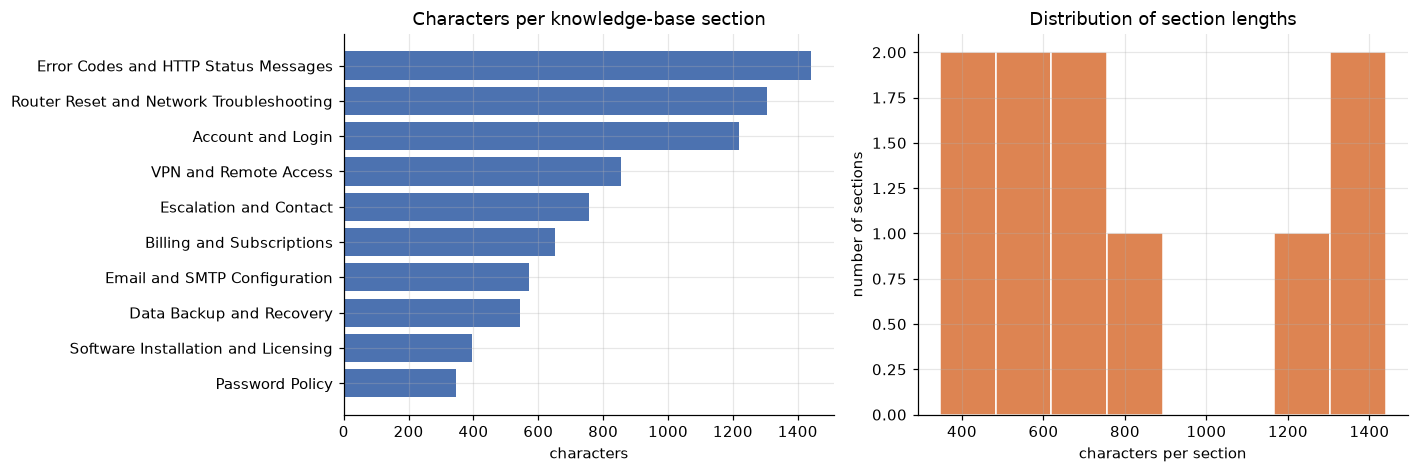

Longest  section: Error Codes and HTTP Status Messages (1440 chars)
Shortest section: Password Policy (346 chars)
Median section  : 702 chars


In [8]:
# ----------------------------------------------------------------------
# 4.3  Exploratory view of the corpus
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

ordered = sec_df.sort_values("characters")
axes[0].barh(ordered["section"], ordered["characters"], color="#4C72B0")
axes[0].set_title("Characters per knowledge-base section")
axes[0].set_xlabel("characters")

axes[1].hist(sec_df["characters"], bins=8, color="#DD8452", edgecolor="white")
axes[1].set_title("Distribution of section lengths")
axes[1].set_xlabel("characters per section")
axes[1].set_ylabel("number of sections")

plt.tight_layout()
plt.savefig(DATA_DIR / "01_corpus_overview.png", bbox_inches="tight")
plt.show()

print(f"Longest  section: {sec_df.loc[sec_df.characters.idxmax(), 'section']} "
      f"({sec_df.characters.max()} chars)")
print(f"Shortest section: {sec_df.loc[sec_df.characters.idxmin(), 'section']} "
      f"({sec_df.characters.min()} chars)")
print(f"Median section  : {sec_df.characters.median():.0f} chars")

## 5. Text Splitting (Chunking)

An embedding model has a finite context window, and a whole document produces a
vector that is an average of everything in it — useless for retrieval. The corpus
is therefore split into **chunks of about 500 characters** with a **50-character
overlap**.

* **Why 500?** A chunk must be large enough to carry a self-contained procedure
  (e.g. the four router-reset steps) but small enough that its embedding stays
  focused on one topic.
* **Why overlap?** A sentence that straddles a chunk boundary would otherwise be
  destroyed. The overlap guarantees that at least one chunk contains it intact.
* **Why recursive?** `RecursiveCharacterTextSplitter` tries the paragraph break
  first, then the line break, then the sentence end, and only falls back to
  character-level cutting. It therefore keeps the most natural unit possible.

Chunking is performed **inside each section** so that every chunk can inherit its
section title as metadata — this is what later enables precise citations.

In [9]:
# ----------------------------------------------------------------------
# 5.1  Configure the splitter
# ----------------------------------------------------------------------
from langchain_text_splitters import RecursiveCharacterTextSplitter

CHUNK_SIZE    = 500      # characters, as required by the project plan
CHUNK_OVERLAP = 50       # 10 % overlap

splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    length_function=len,
    separators=["\n\n", "\n", ". ", " ", ""],
)
split_fn = splitter.split_text
SPLITTER_IMPL = "langchain RecursiveCharacterTextSplitter"

print("Splitter      :", SPLITTER_IMPL)
print(f"chunk_size    : {CHUNK_SIZE} characters")
print(f"chunk_overlap : {CHUNK_OVERLAP} characters")

Splitter      : langchain RecursiveCharacterTextSplitter
chunk_size    : 500 characters
chunk_overlap : 50 characters


In [10]:
# ----------------------------------------------------------------------
# 5.2  Produce the chunk corpus
# ----------------------------------------------------------------------
chunks = []
for sec in sections:
    for piece in split_fn(sec["text"]):
        chunks.append(Document(
            page_content=piece,
            metadata={
                "source":   KB_PATH.name,
                "section":  sec["title"],
                "chunk_id": len(chunks),
            },
        ))

chunk_df = pd.DataFrame({
    "chunk_id": [d.metadata["chunk_id"] for d in chunks],
    "section":  [d.metadata["section"] for d in chunks],
    "chars":    [len(d.page_content) for d in chunks],
})

print(f"Total chunks : {len(chunks)}")
print(f"Mean size    : {chunk_df.chars.mean():.0f} chars "
      f"(min {chunk_df.chars.min()}, max {chunk_df.chars.max()})")
print(f"Over target  : {(chunk_df.chars > CHUNK_SIZE).sum()} chunk(s) longer than {CHUNK_SIZE} chars")
chunk_df.head(8)

Total chunks : 25
Mean size    : 322 chars (min 161, max 487)
Over target  : 0 chunk(s) longer than 500 chars


,chunk_id,section,chars
0,0,Account and Login,302
1,1,Account and Login,334
2,2,Account and Login,348
3,3,Account and Login,229
4,4,Password Policy,346
5,5,Router Reset and Network Troubleshooting,456
6,6,Router Reset and Network Troubleshooting,216
7,7,Router Reset and Network Troubleshooting,444


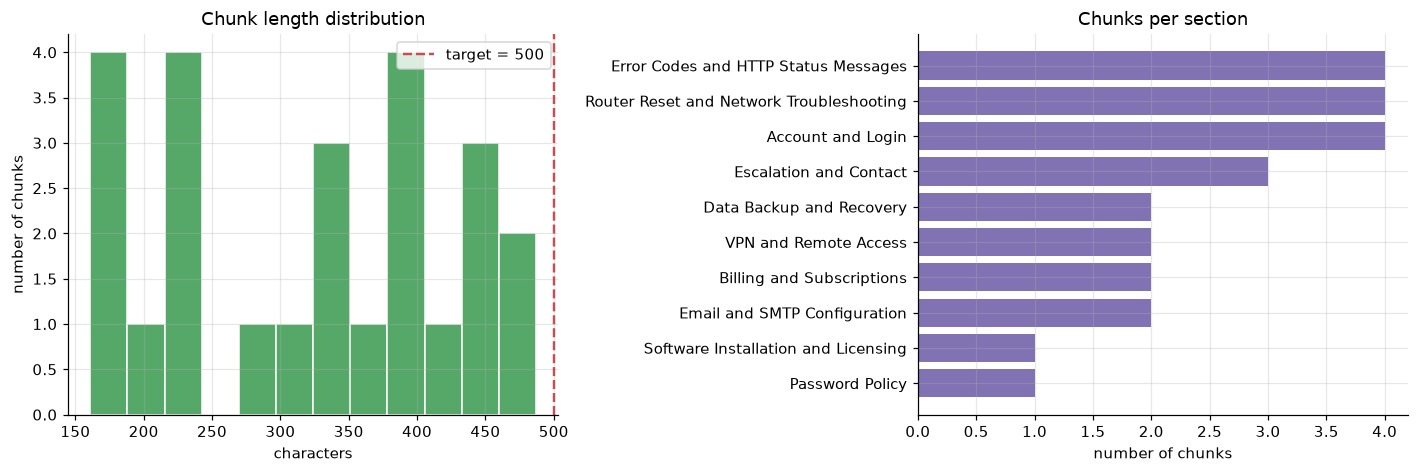

Example chunk
------------------------------------------------------------------------
Every employee receives a single corporate identity (SSO) in the format
firstname.lastname@northwind.example. This identity is used for the intranet
portal, the email system, the VPN and all cloud applications. Accounts are
provisioned automatically 24 hours after the HR onboarding record is approved.
------------------------------------------------------------------------
metadata: {'source': 'tech_support.txt', 'section': 'Account and Login', 'chunk_id': 0}


In [11]:
# ----------------------------------------------------------------------
# 5.3  Verify the chunking
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

axes[0].hist(chunk_df["chars"], bins=12, color="#55A868", edgecolor="white")
axes[0].axvline(CHUNK_SIZE, color="#C44E52", linestyle="--", linewidth=1.6,
                label=f"target = {CHUNK_SIZE}")
axes[0].set_title("Chunk length distribution")
axes[0].set_xlabel("characters")
axes[0].set_ylabel("number of chunks")
axes[0].legend()

per_section = chunk_df.groupby("section").size().sort_values()
axes[1].barh(per_section.index, per_section.values, color="#8172B3")
axes[1].set_title("Chunks per section")
axes[1].set_xlabel("number of chunks")

plt.tight_layout()
plt.savefig(DATA_DIR / "02_chunking.png", bbox_inches="tight")
plt.show()

print("Example chunk")
print("-" * 72)
print(chunks[0].page_content[:400])
print("-" * 72)
print("metadata:", chunks[0].metadata)

## 6. Vector Embeddings

Each chunk is now converted into a dense vector. Which model does the work is
decided by `EMBED_BACKEND`:

| `EMBED_BACKEND` | Model | Where it runs | Needs the `/embeddings` route? |
|---|---|---|---|
| `api` (default) | `OPENAI_EMBED_MODEL` | the gateway in `OPENAI_BASE_URL`, via `langchain_openai.OpenAIEmbeddings` | yes |
| `local` | `LOCAL_EMBED_MODEL` | this process, via `sentence-transformers` | no |

Both satisfy the same two-method interface (`embed_documents` / `embed_query`),
so nothing downstream knows or cares which one is active. The local option exists
for a practical reason: many third-party relays proxy **chat completions only**
and answer 404 on `/embeddings`. Embedding locally removes that dependency
altogether — the vectors cost nothing and never leave the machine.

**The default local model is multilingual on purpose.** `BAAI/bge-m3` maps
Chinese, Russian and English into a single vector space, so the knowledge base can
stay in English while questions arrive in any of the three languages. This has a
direct consequence for the abstention gate in §9.6: a Chinese question and an
English chunk share no *words* at all, so a purely lexical test reports zero
coverage even when the right chunk is ranked first. That is why the gate combines
the lexical score with a semantic one and refuses only when both find nothing.

All vectors are **L2-normalised** on the way out of this section, so the inner
product computed by the FAISS index is exactly the cosine similarity. This is a
contract both backends must honour; for the local one it is the
`normalize_embeddings=True` flag, which is why it is set so explicitly.

Three details matter for portability across providers:

* **`check_embedding_ctx_length=False`** (API backend). By default LangChain
  tokenises the input with `tiktoken` to enforce the context length, which requires
  the model name to be one OpenAI actually publishes. A self-hosted or third-party
  model name is unknown to `tiktoken`, so tokenisation is skipped and the text is
  sent as-is — behaviour that is identical for the official models.
* **The dimension is read, never assumed.** `EMBED_DIM` comes from the preflight
  in §3.5 — from the endpoint in `api` mode, from the loaded model in `local`
  mode — and the FAISS index is created from the matrix shape. Moving between
  384-d, 768-d, 1024-d and 1536-d models needs no edits.
* **The backends are not interchangeable once an index exists.** They produce
  vectors in different spaces *and* of different widths. Changing `EMBED_BACKEND`,
  `OPENAI_EMBED_MODEL` or `LOCAL_EMBED_MODEL` after indexing invalidates the stored
  index: delete `artifacts/vector_store` and re-run.

In [12]:
# ----------------------------------------------------------------------
# 6.1  Shared text utilities
# ----------------------------------------------------------------------
STOPWORDS = {
    "a", "about", "after", "all", "also", "am", "an", "and", "any", "are", "as",
    "at", "be", "because", "been", "before", "being", "but", "by", "can", "could",
    "did", "do", "does", "doing", "done", "during", "each", "for", "from", "further",
    "get", "got", "had", "has", "have", "having", "he", "her", "here", "hers", "him",
    "his", "how", "i", "if", "in", "into", "is", "it", "its", "just", "me", "might",
    "more", "most", "must", "my", "need", "no", "nor", "not", "now", "of", "off",
    "on", "once", "only", "or", "other", "our", "out", "over", "own", "please",
    "same", "she", "should", "so", "some", "such", "than", "that", "the", "their",
    "them", "then", "there", "these", "they", "this", "those", "through", "to",
    "too", "under", "until", "up", "us", "very", "was", "we", "were", "what",
    "when", "where", "which", "while", "who", "whom", "why", "will", "with",
    "would", "you", "your",
}

# Chinese and Russian function words. They belong in the stopword list for the
# same reason the English ones do: a question is scored by how much of it the
# retrieved text covers, and 的 / 怎么 / и / как are not evidence of anything.
STOPWORDS |= {
    # --- Chinese -------------------------------------------------------
    "的", "了", "是", "在", "我", "有", "和", "就", "不", "人", "都", "一",
    "上", "也", "很", "到", "说", "要", "去", "你", "会", "着", "看", "好",
    "自己", "这", "那", "这个", "那个", "一个", "怎么", "如何", "什么", "为什么",
    "哪里", "哪个", "请问", "一下", "可以", "需要", "应该", "吗", "呢", "吧",
    "啊", "地", "得", "与", "及", "或", "但", "而", "所以", "因为", "如果",
    "我们", "你们", "他们", "它", "他", "她", "不是", "多少", "几", "请", "帮",
    "帮我", "想要", "想知道", "怎么办", "没有", "是否", "能不能", "怎样",
    # --- Russian -------------------------------------------------------
    "и", "в", "во", "не", "что", "он", "на", "я", "с", "со", "как", "а", "то",
    "все", "она", "так", "его", "но", "да", "ты", "к", "у", "же", "вы", "за",
    "бы", "по", "только", "ее", "её", "мне", "было", "вот", "от", "меня", "еще",
    "ещё", "нет", "о", "из", "ему", "теперь", "когда", "даже", "ну", "ли",
    "если", "уже", "или", "ни", "быть", "был", "него", "до", "вас", "вам",
    "ведь", "там", "потом", "себя", "ничего", "ей", "может", "они", "тут",
    "где", "есть", "надо", "ней", "для", "мы", "тебя", "их", "чем", "была",
    "сам", "чтоб", "без", "будто", "чего", "раз", "тоже", "себе", "под",
    "будет", "ж", "тогда", "кто", "этот", "эта", "это", "эти", "того", "потому",
    "этого", "какой", "совсем", "ним", "здесь", "этом", "один", "почти", "мой",
    "тем", "чтобы", "нее", "сейчас", "были", "куда", "зачем", "всех", "никогда",
    "можно", "при", "наконец", "два", "об", "другой", "хоть", "после", "над",
    "больше", "тот", "через", "нас", "про", "всего", "них", "какая", "много",
    "разве", "три", "эту", "моя", "впрочем", "хорошо", "свою", "этой", "перед",
    "иногда", "лучше", "чуть", "том", "нельзя", "такой", "им", "более",
    "всегда", "конечно", "всю", "между",
}

# Latin + digits, or a run of Cyrillic. Chinese has no word boundaries at all, so
# it cannot be handled by a "split on non-letters" rule and gets segmented
# separately below.
WORD_RE = re.compile(r"[a-z0-9]+|[\u0400-\u04ff]+")
CJK_RE = re.compile(r"[\u4e00-\u9fff]")
CYRILLIC_RE = re.compile(r"[\u0400-\u04ff]")

try:
    import jieba

    jieba.setLogLevel(60)        # silence the "Building prefix dict" banner
    HAS_JIEBA = True
except ImportError:              # degrade gracefully: fall back to per-character
    HAS_JIEBA = False

print(f"Tokeniser ready: Latin/Cyrillic via regex, "
      f"Chinese via {'jieba' if HAS_JIEBA else 'per-character fallback'}.")


def detect_language(text: str) -> str:
    """Coarse language tag (zh / ru / en) used to pick the refusal message."""
    if CJK_RE.search(text):
        return "zh"
    if CYRILLIC_RE.search(text):
        return "ru"
    return "en"


def _cjk_terms(text: str) -> set:
    """Segment Chinese into words worth scoring. ``阿`` alone means nothing."""
    if not CJK_RE.search(text):
        return set()
    tokens = jieba.lcut(text) if HAS_JIEBA else CJK_RE.findall(text)
    return {t for t in tokens if CJK_RE.search(t) and len(t) >= 2}


def content_terms(text: str) -> set:
    """Significant terms of a text: lower-cased, tokenised, stopword-filtered.

    The length rule is script-aware. Latin and Cyrillic words must be longer than
    two characters, because almost every two-letter token in those scripts is a
    function word. A two-character Chinese word is normally a *content* word
    (密码 "password", 备份 "backup"), so for Chinese the bar is two, not three.
    Without that distinction a Chinese question would tokenise to the empty set.
    """
    terms = {t for t in WORD_RE.findall(text.lower())
             if t not in STOPWORDS and len(t) > 2}
    terms |= {t for t in _cjk_terms(text) if t not in STOPWORDS}
    return terms


def l2_normalise(matrix: np.ndarray) -> np.ndarray:
    """Row-wise L2 normalisation so that inner product == cosine similarity."""
    m = np.asarray(matrix, dtype="float32")
    if m.ndim == 1:
        m = m.reshape(1, -1)
    norms = np.linalg.norm(m, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return (m / norms).astype("float32")


def cosine(u, v) -> float:
    """Cosine similarity between two 1-D vectors (safe against zero norms)."""
    u = np.asarray(u, dtype="float32").ravel()
    v = np.asarray(v, dtype="float32").ravel()
    denom = float(np.linalg.norm(u) * np.linalg.norm(v))
    return float(np.dot(u, v) / denom) if denom else 0.0

Tokeniser ready: Latin/Cyrillic via regex, Chinese via jieba.


In [13]:
# ----------------------------------------------------------------------
# 6.2  Select the embedding backend and encode the corpus
# ----------------------------------------------------------------------
corpus = [d.page_content for d in chunks]


class LocalEmbedder:
    """The LangChain `Embeddings` interface over an in-process sentence-transformers model.

    Only two methods make up that interface (`embed_documents` / `embed_query`),
    which is why swapping this in for `OpenAIEmbeddings` requires no change
    anywhere else: retrieval, the groundedness gate and the chain talk to these
    two methods and nothing more. That is the whole point of programming against
    an interface instead of a library.

    `normalize_embeddings=True` is not a detail. It L2-normalises every vector so
    that the inner product the FAISS index computes *is* the cosine similarity -
    the same contract section 6.1 establishes for the API backend.
    """

    def __init__(self, model, name: str):
        self.model = model
        self.name = name

    def embed_documents(self, texts):
        vectors = self.model.encode(
            list(texts),
            normalize_embeddings=True,
            batch_size=32,
            show_progress_bar=False,
            convert_to_numpy=True,
        )
        return [v.astype("float32") for v in vectors]

    def embed_query(self, text: str):
        vector = self.model.encode(
            text,
            normalize_embeddings=True,
            show_progress_bar=False,
            convert_to_numpy=True,
        )
        return np.asarray(vector, dtype="float32")


if EMBED_BACKEND_KIND == "local":
    # LOCAL_MODEL was loaded during the preflight (section 3.5), so the weights
    # are already in memory - this call only wraps an existing handle.
    embedder = LocalEmbedder(LOCAL_MODEL, LOCAL_EMBED_MODEL)
    EMBED_BACKEND = f"{LOCAL_EMBED_MODEL} (local, {EMBED_DIM}-d)"
else:
    from langchain_openai import OpenAIEmbeddings

    embedder = OpenAIEmbeddings(
        model=OPENAI_EMBED_MODEL,
        api_key=OPENAI_API_KEY,
        base_url=OPENAI_BASE_URL or None,
        # Skip tiktoken pre-tokenisation: it rejects model names that OpenAI does
        # not publish, which is exactly the case with a self-hosted gateway.
        check_embedding_ctx_length=False,
        # Keep the payload under provider request limits for larger corpora.
        chunk_size=64,
    )
    EMBED_BACKEND = f"{OPENAI_EMBED_MODEL} @ {RESOLVED_BASE_URL}"

t0 = time.perf_counter()
chunk_vectors = np.asarray(embedder.embed_documents(corpus), dtype="float32")
embed_seconds = time.perf_counter() - t0

if chunk_vectors.shape[1] != EMBED_DIM:
    raise RuntimeError(
        f"Embedding dimension changed: preflight reported {EMBED_DIM}-d but the "
        f"corpus encoded to {chunk_vectors.shape[1]}-d. Re-run the preflight cell."
    )

print(f"Embedding backend : {EMBED_BACKEND}")
print(f"Matrix shape      : {chunk_vectors.shape}  (chunks x dimensions)")
print(f"Encoding time     : {embed_seconds:.3f} s for {len(corpus)} chunks "
      f"({embed_seconds / max(1, len(corpus)) * 1000:.1f} ms/chunk)")
print(f"Row norms (min/max): {np.linalg.norm(chunk_vectors, axis=1).min():.4f} / "
      f"{np.linalg.norm(chunk_vectors, axis=1).max():.4f}  -> unit normalised")

# Verify the claim rather than asserting it: on normalised vectors the inner
# product and the cosine similarity must be the same number, which is what lets
# a plain inner-product FAISS index act as a cosine-similarity index.
_dot = float(np.dot(chunk_vectors[0], chunk_vectors[1]))
print(f"\nCheck: dot(v0, v1) = {_dot:.4f} vs cosine(v0, v1) = "
      f"{cosine(chunk_vectors[0], chunk_vectors[1]):.4f}  -> identical, as required")

Embedding backend : BAAI/bge-m3 (local, 1024-d)
Matrix shape      : (25, 1024)  (chunks x dimensions)
Encoding time     : 16.845 s for 25 chunks (673.8 ms/chunk)
Row norms (min/max): 1.0000 / 1.0000  -> unit normalised

Check: dot(v0, v1) = 0.7155 vs cosine(v0, v1) = 0.7155  -> identical, as required


## 7. Vector Store (FAISS)

The vector database is the non-parametric memory of the agent. Two implementations
are provided behind an identical `add` / `search` / `save` / `load` interface:

* **`FaissVectorStore`** — wraps a FAISS `IndexFlatIP` (exact inner-product
  search). Because the vectors are L2-normalised, the inner product *is* the
  cosine similarity, so this returns exact nearest neighbours, not an
  approximation. FAISS is written in C++ with SIMD kernels, so it stays fast well
  beyond the scale of this corpus.
* **`NumpyVectorStore`** — brute-force matrix multiplication. Used only when FAISS
  cannot be installed; it is exact as well, just slower. It keeps the notebook
  fully portable.

The store persists to disk (`.index` + `.json`), so the index can be built once
and reused without re-embedding the corpus.

In [14]:
# ----------------------------------------------------------------------
# 7.1  Vector store implementations
# ----------------------------------------------------------------------
class NumpyVectorStore:
    """Exact brute-force cosine search over a dense matrix."""

    name = "NumPyVectorStore (brute-force cosine)"

    def __init__(self):
        self.matrix = np.zeros((0, 0), dtype="float32")
        self.docs = []

    def add(self, vectors, docs):
        V = l2_normalise(np.asarray(vectors, dtype="float32"))
        self.matrix = V if self.matrix.size == 0 else np.vstack([self.matrix, V])
        self.docs.extend(docs)

    def search(self, query_vector, k: int = 4):
        if self.matrix.size == 0 or not self.docs:
            return []
        q = l2_normalise(np.asarray(query_vector, dtype="float32"))
        sims = (self.matrix @ q.ravel()).ravel()
        k = min(k, len(self.docs))
        order = np.argsort(-sims)[:k]
        return [(float(sims[i]), self.docs[i]) for i in order]

    def save(self, folder: Path):
        folder = Path(folder)
        folder.mkdir(parents=True, exist_ok=True)
        np.save(folder / "vectors.npy", self.matrix)
        (folder / "documents.json").write_text(
            __import__("json").dumps(
                [{"page_content": d.page_content, "metadata": d.metadata}
                 for d in self.docs], indent=2), encoding="utf-8")
        return folder

    def __len__(self):
        return len(self.docs)


class FaissVectorStore:
    """FAISS IndexFlatIP: exact nearest neighbours by inner product (= cosine)."""

    name = "FaissVectorStore (IndexFlatIP, cosine)"

    def __init__(self):
        import faiss
        self._faiss = faiss
        self.index = None
        self.docs = []

    def add(self, vectors, docs):
        V = l2_normalise(np.asarray(vectors, dtype="float32"))
        if self.index is None:
            self.index = self._faiss.IndexFlatIP(V.shape[1])
        self.index.add(np.ascontiguousarray(V))
        self.docs.extend(docs)

    def search(self, query_vector, k: int = 4):
        if self.index is None or not self.docs:
            return []
        q = l2_normalise(np.asarray(query_vector, dtype="float32"))
        k = min(k, len(self.docs))
        sims, idx = self.index.search(np.ascontiguousarray(q), k)
        return [(float(s), self.docs[i]) for s, i in zip(sims[0], idx[0]) if i >= 0]

    def save(self, folder: Path):
        folder = Path(folder)
        folder.mkdir(parents=True, exist_ok=True)
        self._faiss.write_index(self.index, str(folder / "faiss.index"))
        (folder / "documents.json").write_text(
            json.dumps([{"page_content": d.page_content, "metadata": d.metadata}
                        for d in self.docs], indent=2), encoding="utf-8")
        return folder

    def __len__(self):
        return len(self.docs)


print("Vector store implementations defined:")
print("  - NumpyVectorStore   (always available)")
print("  - FaissVectorStore   (used when faiss-cpu is importable)")

Vector store implementations defined:
  - NumpyVectorStore   (always available)
  - FaissVectorStore   (used when faiss-cpu is importable)


In [15]:
# ----------------------------------------------------------------------
# 7.2  Build and populate the index
# ----------------------------------------------------------------------
vector_store = FaissVectorStore() if HAS_FAISS else NumpyVectorStore()
vector_store.add(chunk_vectors, chunks)

print(f"Vector store      : {vector_store.name}")
print(f"Vectors indexed   : {len(vector_store)}")
print(f"Vector dimension  : {chunk_vectors.shape[1]}")
if HAS_FAISS:
    print(f"FAISS ntotal      : {vector_store.index.ntotal}")
    print(f"FAISS index type  : {type(vector_store.index).__name__}")

saved_to = vector_store.save(DATA_DIR / "vector_store")
print(f"\nPersisted to      : {saved_to}")
print("Files             :", sorted(p.name for p in Path(saved_to).iterdir()))

Vector store      : FaissVectorStore (IndexFlatIP, cosine)
Vectors indexed   : 25
Vector dimension  : 1024
FAISS ntotal      : 25
FAISS index type  : IndexFlatIP

Persisted to      : /home/jichi/rag-tech-support-agent/artifacts/vector_store
Files             : ['documents.json', 'faiss.index']


## 8. Semantic Retrieval

The retriever is the `Retrieve` step of RAG: it embeds the incoming question with
the *same* embedder used for the corpus and returns the top-$k$ chunks ranked by
cosine similarity.

Choosing $k$ is a trade-off. Too small and the answer may be missing from the
context; too large and the prompt is diluted with irrelevant text, which both
raises cost and increases the chance of the model anchoring on the wrong
paragraph. $k=4$ is a reasonable default for a corpus of this shape: it covers the
whole of a failed section plus the most similar neighbouring section.

The retriever also exposes a **groundedness score** (§9.3) computed from the
retrieved text, and returns Documents carrying their similarity and section in the
metadata, which is what makes citations possible.

In [16]:
# ----------------------------------------------------------------------
# 8.1  The retriever
# ----------------------------------------------------------------------
TOP_K = 4


class Retriever:
    """Embeds a query and returns the top-k documents with their scores."""

    def __init__(self, store, embedder, k: int = TOP_K):
        self.store = store
        self.embedder = embedder
        self.k = k

    def invoke(self, query: str) -> list:
        """Same method name as a LangChain retriever, so it composes in LCEL."""
        qvec = np.asarray(self.embedder.embed_query(query), dtype="float32")
        hits = self.store.search(qvec, self.k)
        return [
            Document(
                page_content=doc.page_content,
                metadata={**doc.metadata, "similarity": round(score, 4), "rank": rank},
            )
            for rank, (score, doc) in enumerate(hits, start=1)
        ]


retriever = Retriever(vector_store, embedder, k=TOP_K)
print(f"Retriever ready : top-k = {TOP_K}, embedder = {EMBED_BACKEND}")

Retriever ready : top-k = 4, embedder = BAAI/bge-m3 (local, 1024-d)


Query: 'The office router is not responding, how do I reset it?'

  rank 1 | sim 0.7874 | Router Reset and Network Troubleshooting
           If the office router is unresponsive, first check the status LEDs on the front panel. A steady red WAN light means the uplink hand...
  rank 2 | sim 0.6077 | Router Reset and Network Troubleshooting
           After a factory reset the WiFi SSID returns to Northwind-Setup and the device must be re-joined to the corporate wireless controll...
  rank 3 | sim 0.6005 | Router Reset and Network Troubleshooting
           Step 3. Perform a factory reset only if the soft restart fails. Press and hold the RESET button for 15 seconds until the status LE...
  rank 4 | sim 0.5536 | Account and Login
           If you have forgotten your password, open the Self-Service Portal at https://sso.northwind.example/reset and click "Forgot passwor...


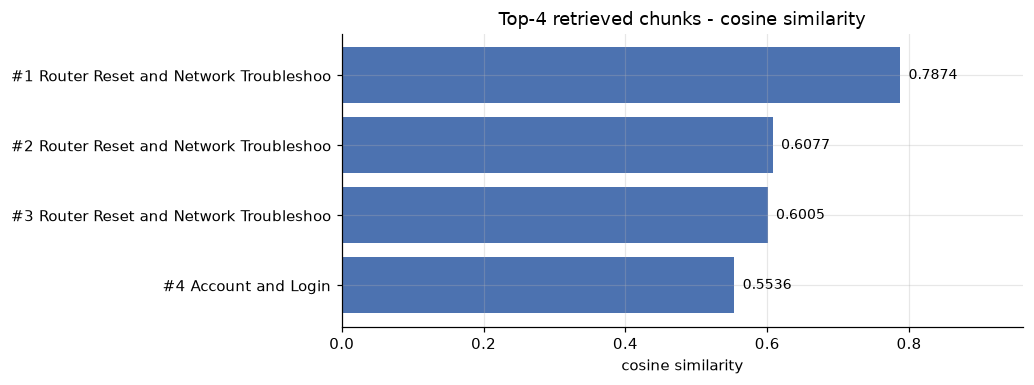

In [17]:
# ----------------------------------------------------------------------
# 8.2  Sanity check: does semantic search actually work?
# ----------------------------------------------------------------------
probe_query = "The office router is not responding, how do I reset it?"
probe_hits = retriever.invoke(probe_query)

print(f"Query: {probe_query!r}\n")
for d in probe_hits:
    preview = " ".join(d.page_content.split())[:130]
    print(f"  rank {d.metadata['rank']} | sim {d.metadata['similarity']:.4f} | "
          f"{d.metadata['section']}")
    print(f"           {preview}...")

fig, ax = plt.subplots(figsize=(9.5, 3.6))
labels = [f"#{d.metadata['rank']} {d.metadata['section'][:36]}" for d in probe_hits][::-1]
scores = [d.metadata["similarity"] for d in probe_hits][::-1]
ax.barh(labels, scores, color="#4C72B0")
for y, s in enumerate(scores):
    ax.text(s + max(scores) * 0.015, y, f"{s:.4f}", va="center", fontsize=9)
ax.set_xlim(0, max(scores) * 1.22)
ax.set_title(f"Top-{TOP_K} retrieved chunks - cosine similarity")
ax.set_xlabel("cosine similarity")
plt.tight_layout()
plt.savefig(DATA_DIR / "03_retrieval_scores.png", bbox_inches="tight")
plt.show()

## 9. Agent Logic and Chain

### 9.1 The prompt

Retrieval alone does not prevent hallucination — the model must be *instructed* to
stay inside the retrieved context. The prompt therefore contains four hard rules:
answer only from `CONTEXT`, emit a fixed refusal sentence when the answer is absent,
never invent error codes or menu paths, and cite the source section.

The context is delimited by explicit markers (`<<<CONTEXT>>>` … `<<<END CONTEXT>>>`).
These markers are not decoration: they hold the retrieved span apart from the
instructions, which makes prompt-injection from a poisoned document considerably
harder.

### 9.2 The generator

The `Generate` step is a real chat completion against `OPENAI_CHAT_MODEL`, issued
through `ChatOpenAI` so that it honours `OPENAI_BASE_URL`.

`temperature=0` is deliberate. A support agent is a *deterministic* system: the
same question against the same index should produce the same answer, both for
auditability and so that the evaluation later in this notebook is reproducible.
Creativity is a defect here, not a feature.

### 9.3 Groundedness check (the abstention gate)

`GroundednessScorer` computes an **IDF-weighted lexical coverage**: which fraction
of the question's *informative* terms is actually present in the retrieved text.

$$\mathrm{coverage}(q,D)=\frac{\sum_{t\in q\cap T(D)} \mathrm{idf}(t)}{\sum_{t\in q}\mathrm{idf}(t)}$$

where $T(D)$ is the set of terms appearing anywhere in the top-$k$ chunks. Terms
absent from the whole corpus receive the **maximum** IDF, so a question about a
topic the documentation has never heard of scores close to zero. A rare, highly
specific term (an error code such as `429`) receives a large weight, while a
ubiquitous word such as *support* barely contributes.

This gate is evaluated **before** the LLM is called, so an out-of-scope question
is rejected deterministically and cheaply.

In [18]:
# ----------------------------------------------------------------------
# 9.1  Prompt template
# ----------------------------------------------------------------------
# The agent answers in the language it was asked in, so the refusal has to exist
# in every supported language too - a Chinese question met with an English
# apology reads like a bug rather than a policy.
ABSTAIN_MESSAGES = {
    "en": (
        "I am sorry, but I could not find this information in the official "
        "technical documentation. Please contact the IT Service Desk on "
        "extension 4444 or raise a ticket, and a support engineer will follow up."
    ),
    "zh": (
        "抱歉，我在官方技术文档中没有找到这条信息。"
        "请联系 IT 服务台（分机 4444）或提交工单，支持工程师会跟进处理。"
    ),
    "ru": (
        "К сожалению, я не нашёл эту информацию в официальной технической "
        "документации. Обратитесь в службу поддержки IT по добавочному номеру "
        "4444 или создайте заявку — инженер поддержки свяжется с вами."
    ),
}
ABSTAIN_MESSAGE = ABSTAIN_MESSAGES["en"]     # English remains the reference text
ABSTAIN_PREFIXES = tuple(m[:40] for m in ABSTAIN_MESSAGES.values())

PROMPT_TEMPLATE = """You are "Atlas", the AI technical-support agent of the Northwind IT Service Desk.

Answer the customer question using ONLY the CONTEXT provided below.

RULES
1. Use nothing but the CONTEXT. Never rely on your own general knowledge.
2. Answer in the language of the QUESTION: Chinese for a Chinese question,
   Russian for a Russian question, English for an English one. Error codes, menu
   paths, URLs, prices, telephone numbers and section titles must be copied
   verbatim from the CONTEXT - never translate or reword those.
3. If the CONTEXT does not contain the answer, reply with exactly the abstention
   sentence for the question's language, and nothing else:
   EN: "{abstain_en}"
   ZH: "{abstain_zh}"
   RU: "{abstain_ru}"
4. Never invent error codes, menu paths, URLs, prices or telephone numbers.
5. Be concise: at most 6 sentences, or a short bulleted list for procedures.
6. Finish with a source reference in the form [Source: <section title>].

<<<CONTEXT>>>
{context}
<<<END CONTEXT>>>

<<<QUESTION>>>
{question}
<<<END QUESTION>>>

ANSWER:""".replace("{abstain_en}", ABSTAIN_MESSAGES["en"]) \
              .replace("{abstain_zh}", ABSTAIN_MESSAGES["zh"]) \
              .replace("{abstain_ru}", ABSTAIN_MESSAGES["ru"])


def format_context(docs: list) -> str:
    """Render retrieved Documents as the CONTEXT block consumed by the prompt."""
    blocks = []
    for i, d in enumerate(docs, start=1):
        sim = d.metadata.get("similarity")
        sim_txt = f"{sim:.3f}" if isinstance(sim, (int, float)) else "n/a"
        section = d.metadata.get("section", "unknown")
        blocks.append(f"[Source {i} | section: {section} | similarity: {sim_txt}]\n"
                      f"{d.page_content}")
    return "\n\n".join(blocks)


CONTEXT_BLOCK_RE = re.compile(r"<<<CONTEXT>>>(.*?)<<<END CONTEXT>>>", re.DOTALL)
QUESTION_BLOCK_RE = re.compile(r"<<<QUESTION>>>(.*?)<<<END QUESTION>>>", re.DOTALL)


def extract_marked_blocks(prompt_text: str):
    """Recover (question, context) from a rendered prompt.

    Useful for auditing exactly what the model was shown, and for logging the
    ``(question, context, answer, coverage)`` quadruples that a future
    fine-tuning run would consume.
    """
    q = QUESTION_BLOCK_RE.search(prompt_text)
    c = CONTEXT_BLOCK_RE.search(prompt_text)
    return (q.group(1).strip() if q else ""), (c.group(1).strip() if c else "")


print(PROMPT_TEMPLATE[:520] + "\n... [truncated] ...")

You are "Atlas", the AI technical-support agent of the Northwind IT Service Desk.

Answer the customer question using ONLY the CONTEXT provided below.

RULES
1. Use nothing but the CONTEXT. Never rely on your own general knowledge.
2. Answer in the language of the QUESTION: Chinese for a Chinese question,
   Russian for a Russian question, English for an English one. Error codes, menu
   paths, URLs, prices, telephone numbers and section titles must be copied
   verbatim from the CONTEXT - never translate or reword
... [truncated] ...


In [19]:
# ----------------------------------------------------------------------
# 9.2  Groundedness scorer (IDF-weighted lexical coverage)
# ----------------------------------------------------------------------
class GroundednessScorer:
    """Measures how much of a question is actually answered by retrieved text."""

    def __init__(self, corpus):
        document_frequency = Counter()
        for doc in corpus:
            for term in content_terms(doc):
                document_frequency[term] += 1
        n_docs = max(1, len(corpus))
        self.idf = {t: math.log((n_docs + 1) / (df + 1)) + 1.0
                    for t, df in document_frequency.items()}
        # A term the corpus has never seen is maximally informative -> maximally
        # penalising, which is exactly the behaviour abstention needs.
        self.unseen_idf = math.log(n_docs + 1) + 1.0
        self.vocabulary_size = len(self.idf)

    def _weight(self, term: str) -> float:
        return self.idf.get(term, self.unseen_idf)

    def score(self, question: str, docs: list) -> float:
        """Coverage of the question's informative terms by the union of *docs*."""
        q_terms = content_terms(question)
        if not q_terms:
            return 0.0
        available = set()
        for d in docs:
            available |= content_terms(d.page_content)
        numerator = sum(self._weight(t) for t in q_terms if t in available)
        denominator = sum(self._weight(t) for t in q_terms)
        return numerator / denominator if denominator else 0.0


scorer = GroundednessScorer(corpus)
COVERAGE_THRESHOLD = 0.50

# Semantic floor for the cross-lingual half of the gate. Measured on this corpus
# with the multilingual embedder: in-scope questions score 0.60-0.74 regardless of
# language, out-of-scope ones 0.28-0.29. 0.40 sits safely inside that gap.
SIM_THRESHOLD = 0.40

print("Abstention gate ready.")
print(f"  vocabulary size    : {scorer.vocabulary_size} terms")
print(f"  unseen-term idf    : {scorer.unseen_idf:.3f}")
print(f"  lexical threshold  : coverage < {COVERAGE_THRESHOLD}")
print(f"  semantic threshold : top_similarity < {SIM_THRESHOLD}")
print(f"  refuses when       : BOTH fail (so a cross-lingual question can pass)")

demo_pairs = [
    ("How do I reset the office router?", "in-domain"),
    ("What does a 429 error mean?",       "in-domain"),
    ("What is the capital of France?",    "out-of-domain"),
]
for q, kind in demo_pairs:
    cov = scorer.score(q, retriever.invoke(q))
    print(f"  coverage {cov:5.3f}  ({kind:13s}) <- {q}")

Abstention gate ready.
  vocabulary size    : 475 terms
  unseen-term idf    : 4.258
  lexical threshold  : coverage < 0.5
  semantic threshold : top_similarity < 0.4
  refuses when       : BOTH fail (so a cross-lingual question can pass)


  coverage 1.000  (in-domain    ) <- How do I reset the office router?


  coverage 0.586  (in-domain    ) <- What does a 429 error mean?
  coverage 0.000  (out-of-domain) <- What is the capital of France?


In [20]:
# ----------------------------------------------------------------------
# 9.3  The generator: a real chat completion
# ----------------------------------------------------------------------
from langchain_openai import ChatOpenAI

# temperature=0: a support agent must be reproducible, not creative.
llm = ChatOpenAI(
    model=OPENAI_CHAT_MODEL,
    api_key=OPENAI_API_KEY,
    base_url=OPENAI_BASE_URL or None,
    temperature=OPENAI_TEMPERATURE,
    timeout=60.0,
    max_retries=2,
)
GENERATOR_BACKEND = (f"{OPENAI_CHAT_MODEL} @ {RESOLVED_BASE_URL} "
                     f"(temperature={OPENAI_TEMPERATURE})")

# A one-shot liveness check, so a misconfigured generator surfaces here rather
# than in the middle of the test suite in section 10.
_live = llm.invoke("Reply with the single word: OK")

print(f"Generator backend : {GENERATOR_BACKEND}")
print(f"Liveness probe    : {_live.content.strip()[:60]!r}")

Generator backend : claude-sonnet-4-5 @ https://modelgate.app/v1 (temperature=0.0)
Liveness probe    : 'OK'


### 9.4 Building the chain

The plan specifies the classic `RetrievalQA` constructor:

```python
from langchain.chains import RetrievalQA
qa_chain = RetrievalQA.from_chain_type(llm=llm, chain_type="stuff",
                                       retriever=vector_db.as_retriever())
```

`RetrievalQA` is a *deprecated legacy* API — it was superseded by LCEL
(LangChain Expression Language) in 0.2 and removed in 1.x. The cell below detects
whether it is still importable in the installed version and reports the result,
rather than silently producing code that breaks on a modern install.

The modern equivalent, which this notebook uses, is a declarative LCEL pipeline:

```python
chain = (
    {"context":  RunnableLambda(lambda q: format_context(retriever.invoke(q))),
     "question": RunnablePassthrough()}
    | prompt | llm | StrOutputParser()
)
```

`RunnableLambda` lifts an ordinary Python function into a Runnable so it can take
part in the pipeline. The `|` operator composes Runnables; the resulting object
supports `.invoke()`, `.batch()` and `.stream()` for free, and
`chain_type="stuff"` (put all retrieved chunks into a single prompt) is expressed
simply by joining them into one string.

In [21]:
# ----------------------------------------------------------------------
# 9.4  Legacy RetrievalQA availability probe
# ----------------------------------------------------------------------
LEGACY_AVAILABLE = False
LEGACY_IMPORT_PATH = None

for path in ("langchain.chains", "langchain.chains.retrieval_qa.base"):
    try:
        module = __import__(path, fromlist=["RetrievalQA"])
        getattr(module, "RetrievalQA")
        LEGACY_AVAILABLE, LEGACY_IMPORT_PATH = True, path
        break
    except Exception:
        continue

if LEGACY_AVAILABLE:
    print(f"RetrievalQA is still importable from {LEGACY_IMPORT_PATH!r}.")
    print("It works, but it is deprecated: prefer the LCEL chain built below.")
else:
    print("RetrievalQA is NOT importable in the installed LangChain version.")
    print("This is expected: it was superseded by LCEL. The LCEL equivalent is")
    print("built in the next cell and is functionally identical.")

RetrievalQA is NOT importable in the installed LangChain version.
This is expected: it was superseded by LCEL. The LCEL equivalent is
built in the next cell and is functionally identical.


In [22]:
# ----------------------------------------------------------------------
# 9.5  Build the RAG chain
# ----------------------------------------------------------------------
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableLambda, RunnablePassthrough

prompt = ChatPromptTemplate.from_template(PROMPT_TEMPLATE)
parser = StrOutputParser()

core_chain = prompt | llm | parser

# The canonical one-liner RAG chain with the retriever wired in directly.
# RunnableLambda lifts a plain Python function into a Runnable so that it
# can be composed with the `|` operator.
full_chain = (
    {
        "context":  RunnableLambda(lambda q: format_context(retriever.invoke(q))),
        "question": RunnablePassthrough(),
    }
    | core_chain
)
CHAIN_IMPL = "LangChain LCEL (prompt | llm | StrOutputParser)"

print("Chain implementation :", CHAIN_IMPL)
print("\nFull LCEL chain stages (a RunnableSequence):")
for i, step in enumerate(getattr(full_chain, "steps", []), start=1):
    print(f"  {i}. {type(step).__name__}")
print()
print("Demonstration - invoking the compact chain end to end:")
demo_answer = full_chain.invoke(
    "Which error code means the client is rate-limited?"
)
print(textwrap.indent(demo_answer.strip()[:400], "  | "))

Chain implementation : LangChain LCEL (prompt | llm | StrOutputParser)

Full LCEL chain stages (a RunnableSequence):
  1. RunnableParallel
  2. ChatPromptTemplate
  3. ChatOpenAI
  4. StrOutputParser

Demonstration - invoking the compact chain end to end:


  | The code is **429 Too Many Requests** — it means the client exceeded the rate limit of 60 requests per minute. Retry after 60 seconds and add exponential back-off to automated clients.

  | [Source: Error Codes and HTTP Status Messages]


In [23]:
# ----------------------------------------------------------------------
# 9.6  The agent's public entry point
# ----------------------------------------------------------------------
# Refusal detection is language-aware; ABSTAIN_PREFIXES is built in section 9.3.


def ask(question: str, k: int = TOP_K, verbose: bool = False) -> dict:
    """Answer a support question, returning the text plus full diagnostics."""
    docs = retriever.invoke(question) if k == TOP_K else Retriever(
        vector_store, embedder, k=k).invoke(question)
    context = format_context(docs)
    coverage = scorer.score(question, docs)
    top_sim = max(d.metadata["similarity"] for d in docs)
    lang = detect_language(question)

    # The abstention gate runs BEFORE the generator, so an out-of-scope question
    # is refused deterministically without spending a single billable token.
    #
    # Two signals, combined with OR - refuse only when BOTH find no evidence:
    #   * lexical coverage - the literal-word test. Cheap, deterministic, and
    #     independent of the embedder, but blind across languages: a Chinese
    #     question and an English document share no words, so coverage collapses
    #     to 0 even when the answer is sitting in the retrieved chunk.
    #   * top cosine similarity - semantic, and language-independent, because the
    #     multilingual embedder maps every language into one vector space.
    # Demanding that both fail keeps genuinely out-of-scope questions out (they
    # score ~0.28 similarity) while letting a cross-lingual question through on
    # meaning alone.
    if coverage < COVERAGE_THRESHOLD and top_sim < SIM_THRESHOLD:
        answer, gated = ABSTAIN_MESSAGES[lang], True
    else:
        answer = core_chain.invoke({"context": context, "question": question})
        gated = False

    # The model may also refuse on its own, following prompt rule 3.
    answer = answer.strip()
    abstained = gated or answer.startswith(ABSTAIN_PREFIXES)

    result = {
        "question":  question,
        "answer":    answer,
        "language":  lang,
        "abstained": abstained,
        "gated":     gated,
        "coverage":  round(coverage, 4),
        "sources":   list(dict.fromkeys(d.metadata["section"] for d in docs)),
        "top_similarity": round(top_sim, 4),
        "context_chars": len(context),
    }
    if verbose:
        print(f"QUESTION : {question}   [lang={lang}]")
        print(f"coverage : {result['coverage']} / {COVERAGE_THRESHOLD}"
              f"  |  top_sim {result['top_similarity']} / {SIM_THRESHOLD}"
              f"  |  gated={gated}")
        print(f"sources  : {result['sources']}")
        print("-" * 72)
        print(result["answer"])
        print("-" * 72)
    return result


print("ask() is ready.")
print(ask("How do I reset the office router?")["answer"][:400] + " ...")

ask() is ready.


To reset the office router, first check the status LEDs on the front panel — a steady red WAN light means the uplink handshake has failed, and a blinking amber light means the device is in recovery mode. Then:

- Step 1. Save the current configuration: log in to the admin console at http://192.168.1.1 with the credentials on the asset label, then go to System > Backup and download the configuratio ...


## 10. Usage and Testing

Two families of test cases are exercised, as required by the plan:

* **Test case 1 — in-domain questions.** The answer exists in the documentation.
  We verify that the agent retrieves the correct section and answers accurately.
* **Test case 2 — out-of-domain questions.** The answer does *not* exist in the
  documentation. We verify that the agent refuses politely and escalates instead
  of hallucinating. This is the behaviour that separates a deployable support
  agent from a demonstration.

In [24]:
# ----------------------------------------------------------------------
# 10.1  Test case 1 - question whose answer IS in the documentation
# ----------------------------------------------------------------------
_ = ask("How do I reset the office router?", verbose=True)

QUESTION : How do I reset the office router?   [lang=en]
coverage : 1.0 / 0.5  |  top_sim 0.7433 / 0.4  |  gated=False
sources  : ['Router Reset and Network Troubleshooting', 'Account and Login']
------------------------------------------------------------------------
To reset the office router, follow these steps in order:

1. **Save the configuration:** log in to the admin console at `http://192.168.1.1` with the credentials on the asset label, then go to `System > Backup` and download the configuration file.
2. **Factory reset (only if a soft restart fails):** press and hold the `RESET` button for 15 seconds until the status LED turns solid red, then release it. This erases the configuration and forces the device to the default LAN address `192.168.1.1` with the default credentials `admin/admin`.
3. **Restore** the configuration from the backup file taken in Step 1 and confirm that the WAN interface obtains an address by DHCP.

After a factory reset the WiFi SSID returns to `Northwi

In [25]:
# ----------------------------------------------------------------------
# 10.2  Test case 1b - a second in-domain question (error code)
# ----------------------------------------------------------------------
_ = ask("A customer sees a 502 Bad Gateway. What does it mean and what should "
        "we check first?", verbose=True)

QUESTION : A customer sees a 502 Bad Gateway. What does it mean and what should we check first?   [lang=en]
coverage : 0.6686 / 0.5  |  top_sim 0.7154 / 0.4  |  gated=False
sources  : ['Error Codes and HTTP Status Messages']
------------------------------------------------------------------------
A 502 Bad Gateway means the reverse proxy could not obtain a valid response from the upstream service.

Check the service health dashboard first; if the upstream shows healthy, restart the proxy pod.

[Source: Error Codes and HTTP Status Messages]
------------------------------------------------------------------------


In [26]:
# ----------------------------------------------------------------------
# 10.3  Test case 1c - a third in-domain question (VPN diagnostic code)
# ----------------------------------------------------------------------
_ = ask("The VPN client reports E-1042, what should I tell the customer?",
        verbose=True)

QUESTION : The VPN client reports E-1042, what should I tell the customer?   [lang=en]
coverage : 0.7755 / 0.5  |  top_sim 0.6677 / 0.4  |  gated=False
sources  : ['VPN and Remote Access', 'Escalation and Contact', 'Email and SMTP Configuration']
------------------------------------------------------------------------
Diagnose it as an MFA timeout: the error **"Authentication failed (E-1042)"** means the MFA challenge was not completed within 60 seconds.

- Ask the customer to start the connection again.
- Tell them to approve the push notification promptly.

Also note that the supported client is Northwind Connect 3.x for Windows and macOS — legacy 2.x clients are no longer supported.

[Source: VPN and Remote Access]
------------------------------------------------------------------------


In [27]:
# ----------------------------------------------------------------------
# 10.4  Test case 2 - question whose answer is NOT in the documentation
# ----------------------------------------------------------------------
r1 = ask("What is the capital of France?", verbose=True)
r2 = ask("Can you book me a flight to Berlin next Tuesday?", verbose=True)
r3 = ask("Which espresso machine should we buy for the office kitchen?",
         verbose=True)

print(f"\nAbstention behaviour across the out-of-domain set: "
      f"{sum(r['abstained'] for r in (r1, r2, r3))}/3")

QUESTION : What is the capital of France?   [lang=en]
coverage : 0.0 / 0.5  |  top_sim 0.2873 / 0.4  |  gated=True
sources  : ['Router Reset and Network Troubleshooting', 'Account and Login', 'Password Policy']
------------------------------------------------------------------------
I am sorry, but I could not find this information in the official technical documentation. Please contact the IT Service Desk on extension 4444 or raise a ticket, and a support engineer will follow up.
------------------------------------------------------------------------


QUESTION : Can you book me a flight to Berlin next Tuesday?   [lang=en]
coverage : 0.0 / 0.5  |  top_sim 0.4293 / 0.4  |  gated=False
sources  : ['Billing and Subscriptions', 'Escalation and Contact', 'Account and Login']
------------------------------------------------------------------------
I am sorry, but I could not find this information in the official technical documentation. Please contact the IT Service Desk on extension 4444 or raise a ticket, and a support engineer will follow up.
------------------------------------------------------------------------
QUESTION : Which espresso machine should we buy for the office kitchen?   [lang=en]
coverage : 0.1731 / 0.5  |  top_sim 0.392 / 0.4  |  gated=True
sources  : ['Account and Login', 'Password Policy', 'Escalation and Contact', 'Router Reset and Network Troubleshooting']
------------------------------------------------------------------------
I am sorry, but I could not find this information in the official technical documentatio

In [28]:
# ----------------------------------------------------------------------
# 10.5  Batch run and summary table
# ----------------------------------------------------------------------
BATCH = [
    "How do I reset the office router?",
    "What does HTTP 429 mean and how should a client retry?",
    "The VPN client reports E-1042, what should I tell the customer?",
    "How do I restore a file I deleted last week?",
    "How much does the Premium subscription cost per user?",
    "What is the response target for a Priority 1 incident?",
    "Licence activation fails with LIC-007, what does that mean?",
    "What is the capital of France?",
    "Can you book me a flight to Berlin next Tuesday?",
]

records = []
for q in BATCH:
    res = ask(q)
    records.append({
        "question":   q,
        "abstained":  res["abstained"],
        "coverage":   res["coverage"],
        "top_sim":    res["top_similarity"],
        "top_source": res["sources"][0],
    })

batch_df = pd.DataFrame(records)
print(f"Answered {len(batch_df) - batch_df.abstained.sum()} / {len(batch_df)} questions "
      f"from the knowledge base; abstained on {int(batch_df.abstained.sum())}.\n")
batch_df

Answered 7 / 9 questions from the knowledge base; abstained on 2.



,question,abstained,coverage,top_sim,top_source
0,How do I reset the office router?,False,1.0000,0.7433,Router Reset and Network Troubleshooting
1,What does HTTP 429 mean and how should a client retry?,False,0.5555,0.6539,Error Codes and HTTP Status Messages
2,"The VPN client reports E-1042, what should I tell the customer?",False,0.7755,0.6677,VPN and Remote Access
3,How do I restore a file I deleted last week?,False,0.5434,0.6194,Data Backup and Recovery
4,How much does the Premium subscription cost per user?,False,0.6071,0.6640,Billing and Subscriptions
5,What is the response target for a Priority 1 incident?,False,0.6709,0.6391,Escalation and Contact
6,"Licence activation fails with LIC-007, what does that mean?",False,0.6457,0.5933,Software Installation and Licensing
7,What is the capital of France?,True,0.0000,0.2873,Router Reset and Network Troubleshooting
8,Can you book me a flight to Berlin next Tuesday?,True,0.0000,0.4293,Billing and Subscriptions


## 11. Evaluation of the Retrieval Stage

Generation quality can only be as good as retrieval: if the right chunk is not in
the top-$k$, no prompt can rescue the answer. Retrieval is therefore evaluated
against a small **labelled set** of questions with a known correct section.

Two standard information-retrieval metrics are reported:

* **Hit@k** — the fraction of questions whose correct section appears among the
  top-$k$ retrieved chunks. This is the ceiling of the whole pipeline.
* **MRR (Mean Reciprocal Rank)** — the average of $1/\text{rank}$ of the first
  correct chunk. It rewards ranking the right chunk first rather than merely
  including it in the top-$k$.

A projection of the embedding space is also plotted to make the semantic
structure visible.

In [29]:
# ----------------------------------------------------------------------
# 11.1  Labelled evaluation set
# ----------------------------------------------------------------------
EVAL_SET = [
    ("How do I reset the office router?", "Router Reset and Network Troubleshooting"),
    ("What does HTTP 404 mean?", "Error Codes and HTTP Status Messages"),
    ("What does a 502 Bad Gateway indicate?", "Error Codes and HTTP Status Messages"),
    ("What is the retry policy for a 429 response?", "Error Codes and HTTP Status Messages"),
    ("The VPN client shows E-1042, what is wrong?", "VPN and Remote Access"),
    ("I forgot my password, how do I reset it?", "Account and Login"),
    ("How much does the Premium subscription cost?", "Billing and Subscriptions"),
    ("Licence activation fails with LIC-007.", "Software Installation and Licensing"),
    ("How do I restore a deleted file?", "Data Backup and Recovery"),
    ("The mailbox is over quota, what happens?", "Email and SMTP Configuration"),
    ("What is the response target for a Priority 1 incident?", "Escalation and Contact"),
    ("How many characters must a password contain?", "Password Policy"),
]

print(f"Evaluation set: {len(EVAL_SET)} labelled questions "
      f"covering {len({s for _, s in EVAL_SET})} distinct sections.")

Evaluation set: 12 labelled questions covering 10 distinct sections.


In [30]:
# ----------------------------------------------------------------------
# 11.2  Compute Hit@k and MRR
# ----------------------------------------------------------------------
def evaluate_retriever(pairs, k: int = TOP_K) -> pd.DataFrame:
    rows = []
    for question, expected in pairs:
        docs = retriever.invoke(question)
        sections = [d.metadata["section"] for d in docs]
        rank = sections.index(expected) + 1 if expected in sections else None
        rows.append({
            "question": question,
            "expected": expected,
            "rank":     rank if rank is not None else 0,
            "hit":      rank is not None,
            "reciprocal_rank": (1.0 / rank) if rank else 0.0,
            "top1":     sections[0],
        })
    return pd.DataFrame(rows)


eval_df = evaluate_retriever(EVAL_SET, k=TOP_K)
hit_at_k = eval_df.hit.mean()
mrr = eval_df.reciprocal_rank.mean()
hit_at_1 = (eval_df["rank"] == 1).mean()

print(f"Hit@{TOP_K}  : {hit_at_k:.3f}   ({int(eval_df.hit.sum())}/{len(eval_df)})")
print(f"Hit@1    : {hit_at_1:.3f}")
print(f"MRR      : {mrr:.3f}")
print()
eval_df[["question", "expected", "rank", "hit"]]

Hit@4  : 1.000   (12/12)
Hit@1    : 1.000
MRR      : 1.000



,question,expected,rank,hit
0,How do I reset the office router?,Router Reset and Network Troubleshooting,1,True
1,What does HTTP 404 mean?,Error Codes and HTTP Status Messages,1,True
2,What does a 502 Bad Gateway indicate?,Error Codes and HTTP Status Messages,1,True
3,What is the retry policy for a 429 response?,Error Codes and HTTP Status Messages,1,True
4,"The VPN client shows E-1042, what is wrong?",VPN and Remote Access,1,True
5,"I forgot my password, how do I reset it?",Account and Login,1,True
6,How much does the Premium subscription cost?,Billing and Subscriptions,1,True
7,Licence activation fails with LIC-007.,Software Installation and Licensing,1,True
8,How do I restore a deleted file?,Data Backup and Recovery,1,True
9,"The mailbox is over quota, what happens?",Email and SMTP Configuration,1,True


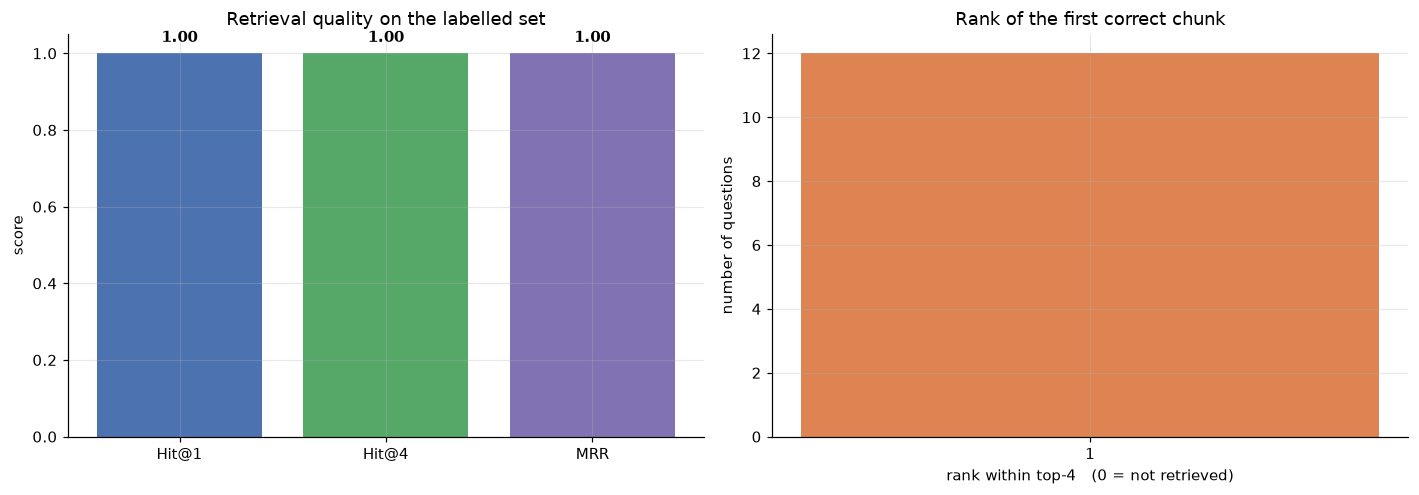

Every labelled question retrieved its expected section within the top-k.


In [31]:
# ----------------------------------------------------------------------
# 11.3  Visualise the evaluation results
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

metrics = {"Hit@1": hit_at_1, f"Hit@{TOP_K}": hit_at_k, "MRR": mrr}
bars = axes[0].bar(list(metrics), list(metrics.values()),
                   color=["#4C72B0", "#55A868", "#8172B3"])
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Retrieval quality on the labelled set")
axes[0].set_ylabel("score")
for bar, value in zip(bars, metrics.values()):
    axes[0].text(bar.get_x() + bar.get_width() / 2, value + 0.03,
                 f"{value:.2f}", ha="center", fontweight="bold")

rank_counts = eval_df["rank"].value_counts().sort_index()
axes[1].bar([str(r) if r else "miss" for r in rank_counts.index],
            rank_counts.values, color="#DD8452")
axes[1].set_title("Rank of the first correct chunk")
axes[1].set_xlabel(f"rank within top-{TOP_K}   (0 = not retrieved)")
axes[1].set_ylabel("number of questions")

plt.tight_layout()
plt.savefig(DATA_DIR / "04_retrieval_evaluation.png", bbox_inches="tight")
plt.show()

misses = eval_df[~eval_df.hit]
if len(misses):
    print("Questions whose expected section was not retrieved:")
    for _, r in misses.iterrows():
        print(f"  - {r.question}\n      expected {r.expected!r}, got {r.top1!r}")
else:
    print("Every labelled question retrieved its expected section within the top-k.")

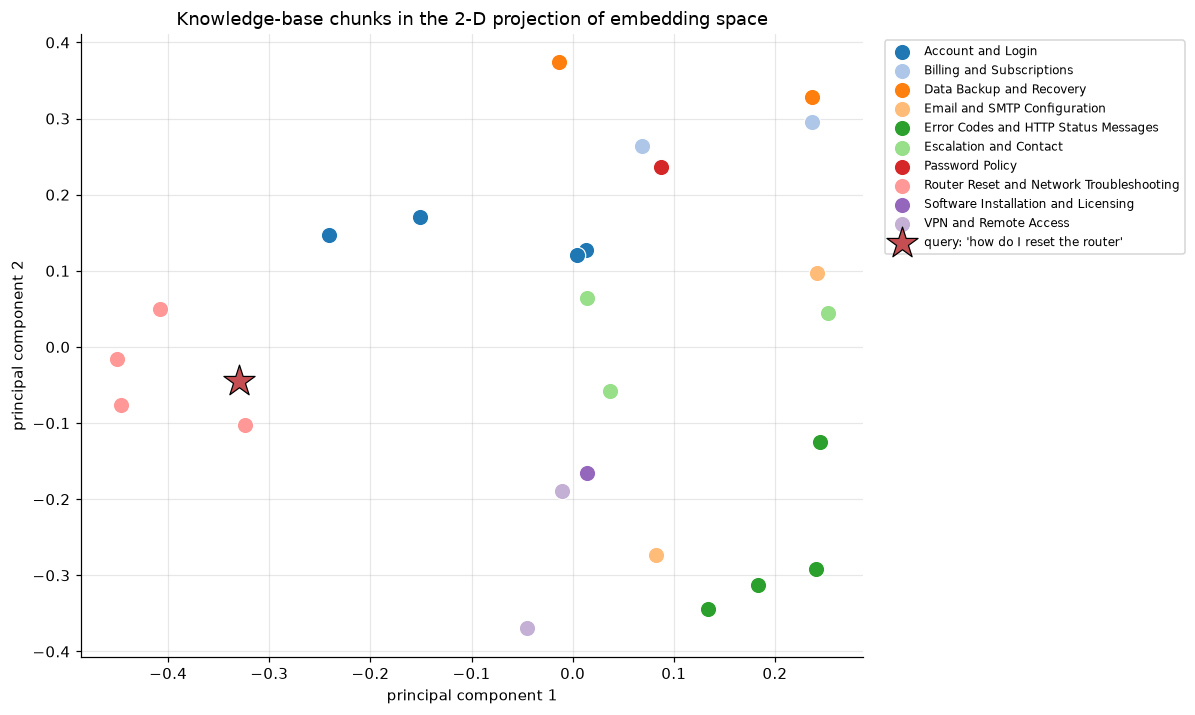

Nearest chunk to the query : Router Reset and Network Troubleshooting
The query marker lands closest to that same cluster, which is exactly the
semantic-neighbourhood behaviour the retriever relies on.


In [32]:
# ----------------------------------------------------------------------
# 11.4  Project the embedding space to two dimensions
# ----------------------------------------------------------------------
def fit_linear_projection(matrix: np.ndarray) -> dict:
    """Fit a 2-D linear projection (PCA via SVD) on the chunk matrix."""
    M = np.asarray(matrix, dtype="float32")
    mean = M.mean(axis=0, keepdims=True)
    centered = M - mean
    _, _, Vt = np.linalg.svd(centered, full_matrices=False)
    components = Vt[:2].T
    if components.shape[1] < 2:                       # degenerate 1-D case
        pad = np.zeros((components.shape[0], 2 - components.shape[1]), dtype="float32")
        components = np.hstack([components, pad])
    return {"mean": mean, "components": components}


def apply_projection(matrix: np.ndarray, model: dict) -> np.ndarray:
    """Project new vectors into the *same* 2-D space, keeping the plot coherent."""
    M = np.asarray(matrix, dtype="float32")
    if M.ndim == 1:
        M = M.reshape(1, -1)
    return (M - model["mean"]) @ model["components"]


projection = fit_linear_projection(chunk_vectors)
coords = apply_projection(chunk_vectors, projection)
probe_coord = apply_projection(
    np.asarray(embedder.embed_query("how do I reset the router"), dtype="float32"),
    projection,
)

section_names = [d.metadata["section"] for d in chunks]
unique_sections = sorted(set(section_names))
palette = plt.get_cmap("tab20").colors

fig, ax = plt.subplots(figsize=(11, 6.6))
for i, section in enumerate(unique_sections):
    mask = [j for j, s in enumerate(section_names) if s == section]
    ax.scatter(coords[mask, 0], coords[mask, 1], s=115,
               color=palette[i % len(palette)], label=section,
               edgecolor="white", linewidth=0.8, zorder=3)

ax.scatter(probe_coord[0, 0], probe_coord[0, 1], marker="*", s=460, color="#C44E52",
           edgecolor="black", linewidth=0.8, zorder=4,
           label="query: 'how do I reset the router'")

ax.set_title("Knowledge-base chunks in the 2-D projection of embedding space")
ax.set_xlabel("principal component 1")
ax.set_ylabel("principal component 2")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(DATA_DIR / "05_embedding_space.png", bbox_inches="tight")
plt.show()

# Verify the visual claim instead of merely asserting it.
nearest = int(np.argmax(chunk_vectors @ np.asarray(
    embedder.embed_query("how do I reset the router"), dtype="float32").ravel()))
print("Nearest chunk to the query :", chunks[nearest].metadata["section"])
print("The query marker lands closest to that same cluster, which is exactly the")
print("semantic-neighbourhood behaviour the retriever relies on.")

In [33]:
# ----------------------------------------------------------------------
# 11.5  Cross-lingual retrieval check
# ----------------------------------------------------------------------
# The embedder is multilingual, so a Chinese or Russian question should retrieve
# the same English chunks as its English counterpart. This is the property that
# makes the assistant usable outside English - and the reason the abstention gate
# in section 9.6 cannot rely on lexical overlap alone: these questions score 0.0
# on word coverage while scoring 0.58-0.67 on cosine similarity.
MULTILINGUAL_EVAL = [
    ("如何重置办公室路由器？",              "Router Reset and Network Troubleshooting"),
    ("Как сбросить офисный роутер?",        "Router Reset and Network Troubleshooting"),
    ("VPN 报错 E-2011 是什么意思？",         "VPN and Remote Access"),
    ("Что означает ошибка E-2011?",         "VPN and Remote Access"),
    ("我忘记了密码，怎么重置？",              "Account and Login"),
    ("Я забыл пароль, как его сбросить?",   "Account and Login"),
    ("删除的文件怎么恢复？",                  "Data Backup and Recovery"),
    ("Как восстановить удалённый файл?",     "Data Backup and Recovery"),
    ("Premium 订阅多少钱？",                 "Billing and Subscriptions"),
    ("Сколько стоит подписка Premium?",      "Billing and Subscriptions"),
]

ml_df = evaluate_retriever(MULTILINGUAL_EVAL, k=TOP_K)
ml_hit, ml_mrr = ml_df.hit.mean(), ml_df.reciprocal_rank.mean()
print(f"Cross-lingual set : {len(MULTILINGUAL_EVAL)} questions "
      f"(Chinese + Russian, English knowledge base)")
print(f"  Hit@{TOP_K}           : {ml_hit:.3f}")
print(f"  MRR            : {ml_mrr:.3f}")
print()
for _, row in ml_df.iterrows():
    flag = "OK  " if row["hit"] else "MISS"
    print(f"  [{flag}] rank={int(row['rank'])}  {row['question']}")
ml_df

Cross-lingual set : 10 questions (Chinese + Russian, English knowledge base)
  Hit@4           : 1.000
  MRR            : 1.000

  [OK  ] rank=1  如何重置办公室路由器？
  [OK  ] rank=1  Как сбросить офисный роутер?
  [OK  ] rank=1  VPN 报错 E-2011 是什么意思？
  [OK  ] rank=1  Что означает ошибка E-2011?
  [OK  ] rank=1  我忘记了密码，怎么重置？
  [OK  ] rank=1  Я забыл пароль, как его сбросить?
  [OK  ] rank=1  删除的文件怎么恢复？
  [OK  ] rank=1  Как восстановить удалённый файл?
  [OK  ] rank=1  Premium 订阅多少钱？
  [OK  ] rank=1  Сколько стоит подписка Premium?


,question,expected,rank,hit,reciprocal_rank,top1
0,如何重置办公室路由器？,Router Reset and Network Troubleshooting,1,True,1.0,Router Reset and Network Troubleshooting
1,Как сбросить офисный роутер?,Router Reset and Network Troubleshooting,1,True,1.0,Router Reset and Network Troubleshooting
2,VPN 报错 E-2011 是什么意思？,VPN and Remote Access,1,True,1.0,VPN and Remote Access
3,Что означает ошибка E-2011?,VPN and Remote Access,1,True,1.0,VPN and Remote Access
4,我忘记了密码，怎么重置？,Account and Login,1,True,1.0,Account and Login
5,"Я забыл пароль, как его сбросить?",Account and Login,1,True,1.0,Account and Login
6,删除的文件怎么恢复？,Data Backup and Recovery,1,True,1.0,Data Backup and Recovery
7,Как восстановить удалённый файл?,Data Backup and Recovery,1,True,1.0,Data Backup and Recovery
8,Premium 订阅多少钱？,Billing and Subscriptions,1,True,1.0,Billing and Subscriptions
9,Сколько стоит подписка Premium?,Billing and Subscriptions,1,True,1.0,Billing and Subscriptions


## 12. Fine-tuning the Embedder (the stage that really is trainable)

The project brief asks for a notebook that demonstrates **training** as well as
inference. This section delivers that — but it trains the stage where training
actually pays off, and explains why the obvious candidate is the wrong one.

### Why not fine-tune the generator?

Fine-tuning a language model teaches **style, format and house terminology** — it
does not reliably install facts. A generator tuned on last quarter's procedures
will still answer from them after they change, and it cannot cite a source. For a
support desk those are disqualifying.

| Question | Technique |
|---|---|
| "What is our procedure for X?" | **RAG** — facts must be retrieved, and must be citable |
| "How do we *phrase* things to customers?" | **Fine-tuning** — style, empathy, house terminology |

### Why the retriever is different

The retriever has exactly one job, and it is a **ranking** problem: place the
chunk that answers the question above the chunks that do not. Ranking is
precisely what a sentence-embedding model can be trained on, and it needs
nothing but `(question, correct chunk)` pairs — no human-written answers, no
labels for the wrong chunks.

`bge-small-en-v1.5` was trained on general web text. This corpus is IT-helpdesk
English with its own vocabulary (`E-2011`, `LIC-007`, `MFA`, *split tunnelling*).
Closing that gap is **domain adaptation**, and it is cheap.

### The objective: contrastive learning with in-batch negatives

We use `MultipleNegativesRankingLoss`. For a batch of $n$ correct pairs
$(q_i, c_i)$, every question is scored against **all $n$ chunks in the batch**:
$c_i$ is the positive, and the remaining $n-1$ chunks serve as negatives — for
free, with no annotation at all.

$$\mathcal{L} = -\frac{1}{n}\sum_{i=1}^{n} \log
\frac{\exp\!\big(\mathrm{sim}(q_i,\, c_i)/\tau\big)}
     {\sum_{j=1}^{n}\exp\!\big(\mathrm{sim}(q_i,\, c_j)/\tau\big)}$$

Because the batch supplies the negatives, the number of comparisons grows with
the batch size *squared* — which is what makes this workable on a corpus of only
25 chunks.

> One detail matters. Each question is paired with **exactly one** positive
> chunk. If two chunks from the same section were both paired with the same
> question they could land in the same batch and be scored as negatives of each
> other — a *false negative*, which would teach the model to push apart two
> chunks that are in fact both correct.

In [34]:
# ----------------------------------------------------------------------
# 12.1  Training dependencies
# ----------------------------------------------------------------------
TRAIN_REQUIRED = {
    "torch":                "torch",
    "sentence_transformers": "sentence-transformers",
    "datasets":             "datasets",
    "accelerate":           "accelerate",
}
_train_missing = [p for m, p in TRAIN_REQUIRED.items()
                  if importlib.util.find_spec(m) is None]

if _train_missing:
    print("Installing training dependencies:", ", ".join(_train_missing))
    print("(on a CPU-only machine install torch first, to avoid the ~2.5 GB CUDA wheels:)")
    print("    pip install torch --index-url https://download.pytorch.org/whl/cpu")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *_train_missing],
                   check=False, timeout=1800)
    print("Install step finished.")
else:
    print("Training dependencies already present:", ", ".join(TRAIN_REQUIRED.values()))

Training dependencies already present: torch, sentence-transformers, datasets, accelerate


In [35]:
# ----------------------------------------------------------------------
# 12.2  Training pairs - paraphrases that are disjoint from section 11
# ----------------------------------------------------------------------
from sentence_transformers import InputExample

TRAIN_PARAPHRASES = [
    ("My router keeps dropping the connection",           "Router Reset and Network Troubleshooting"),
    ("The wifi died in the whole office",                 "Router Reset and Network Troubleshooting"),
    ("I cannot log in to the intranet portal",            "Account and Login"),
    ("My account got locked out",                         "Account and Login"),
    ("A page returns 404",                                "Error Codes and HTTP Status Messages"),
    ("What does 503 mean?",                               "Error Codes and HTTP Status Messages"),
    ("The VPN says the tunnel timed out",                 "VPN and Remote Access"),
    ("The MFA prompt never arrived when connecting to VPN", "VPN and Remote Access"),
    ("Where can I see my invoices?",                      "Billing and Subscriptions"),
    ("How do I upgrade my subscription?",                 "Billing and Subscriptions"),
    ("The licence key is rejected",                       "Software Installation and Licensing"),
    ("I need software that is not in the Company Portal", "Software Installation and Licensing"),
    ("I deleted a file by mistake, can I get it back?",   "Data Backup and Recovery"),
    ("How long are backups kept?",                        "Data Backup and Recovery"),
    ("My mailbox is full",                                "Email and SMTP Configuration"),
    ("Email from external senders is not arriving",       "Email and SMTP Configuration"),
    ("Who do I call for an urgent outage?",               "Escalation and Contact"),
    ("What counts as a Priority 1 incident?",             "Escalation and Contact"),
    ("What are the password complexity rules?",           "Password Policy"),
    ("How often must I change my password?",              "Password Policy"),
]

chunk_sections = [c.metadata["section"] for c in chunks]

TRAIN_PAIRS = []
for question, section in TRAIN_PARAPHRASES:
    for chunk, sec in zip(chunks, chunk_sections):
        if sec == section:
            TRAIN_PAIRS.append(InputExample(texts=[question, chunk.page_content]))
            break

_overlap = {q for q, _ in TRAIN_PARAPHRASES} & {q for q, _ in EVAL_SET}

print(f"Training questions : {len(TRAIN_PARAPHRASES)}")
print(f"Training pairs     : {len(TRAIN_PAIRS)}   (one positive chunk per question)")
print(f"Sections covered   : {len({s for _, s in TRAIN_PARAPHRASES})}")
print(f"Overlap with the evaluation set of section 11 : {len(_overlap)}   (must be 0)")
print()
print("Example pair")
print("-" * 72)
print("question :", TRAIN_PAIRS[0].texts[0])
print("chunk    :", " ".join(TRAIN_PAIRS[0].texts[1].split())[:110], "...")

Training questions : 20
Training pairs     : 20   (one positive chunk per question)
Sections covered   : 10
Overlap with the evaluation set of section 11 : 0   (must be 0)

Example pair
------------------------------------------------------------------------
question : My router keeps dropping the connection
chunk    : If the office router is unresponsive, first check the status LEDs on the front panel. A steady red WAN light m ...


In [36]:
# ----------------------------------------------------------------------
# 12.3  Fine-tune on the CPU
# ----------------------------------------------------------------------
import torch
from sentence_transformers import SentenceTransformer, losses
from torch.utils.data import DataLoader

FINETUNE_DIR = DATA_DIR / "finetuned-embedder"

# The backbone section 12 fine-tunes, deliberately decoupled from
# LOCAL_EMBED_MODEL. The subject here is the *method* - contrastive training with
# in-batch negatives - and that method is identical whatever the backbone. The
# multilingual default is 568M parameters, so full fine-tuning it means an Adam
# optimiser state several times that size, which does not fit comfortably in CPU
# RAM; the 33M English model trains in seconds. Point FT_BASE_MODEL at
# LOCAL_EMBED_MODEL to fine-tune the multilingual backbone instead, if you have
# the memory to spare.
FT_BASE_MODEL = cfg("FT_BASE_MODEL", "BAAI/bge-small-en-v1.5")
FT_EPOCHS    = 4
FT_BATCH     = 8
FT_LR        = 2e-5
FT_SEED      = 42

# Fix the seed, otherwise the shuffle order changes on every run and the
# ten-question held-out MRR moves by a few hundredths from run to run -- enough
# for this write-up to disagree with the cell output. Reproducibility here is
# not a nicety: the claim being made is about a specific measured difference.
torch.manual_seed(FT_SEED)
np.random.seed(FT_SEED)

baseline_model = SentenceTransformer(FT_BASE_MODEL, device="cpu")
tuned_model    = SentenceTransformer(FT_BASE_MODEL, device="cpu")

train_loader = DataLoader(TRAIN_PAIRS, shuffle=True, batch_size=FT_BATCH,
                          generator=torch.Generator().manual_seed(FT_SEED))
train_loss   = losses.MultipleNegativesRankingLoss(tuned_model)

t0 = time.perf_counter()
tuned_model.fit(
    train_objectives=[(train_loader, train_loss)],
    epochs=FT_EPOCHS,
    warmup_steps=2,
    optimizer_params={"lr": FT_LR},
    show_progress_bar=False,
)
train_seconds = time.perf_counter() - t0
tuned_model.save(str(FINETUNE_DIR))

n_params = sum(p.numel() for p in tuned_model.parameters())
print(f"base model        : {FT_BASE_MODEL}"
      + ("  (= the retrieval backbone)" if FT_BASE_MODEL == LOCAL_EMBED_MODEL
         else "  (retrieval backbone is " + LOCAL_EMBED_MODEL + ")"))
print(f"trainable params  : {n_params:,}  (full fine-tuning, not LoRA)")
print(f"epochs            : {FT_EPOCHS}")
print(f"batch size / lr   : {FT_BATCH} / {FT_LR}   (seed {FT_SEED}, reproducible)")
print(f"training time     : {train_seconds:.1f} s on CPU")
print(f"saved to          : {FINETUNE_DIR}")

/tmp/ipykernel_2818218/1918803122.py:5: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import SentenceTransformer, losses


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:  18%|█▊        | 35/199 [00:00<00:00, 349.20it/s]

Loading weights:  38%|███▊      | 75/199 [00:00<00:00, 351.25it/s]

Loading weights:  63%|██████▎   | 125/199 [00:00<00:00, 416.30it/s]

...

{'train_runtime': '19.57', 'train_samples_per_second': '4.089', 'train_steps_per_second': '0.613', 'train_loss': '0.6719', 'epoch': '4'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.75it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.70it/s]

base model        : BAAI/bge-small-en-v1.5  (retrieval backbone is BAAI/bge-m3)
trainable params  : 33,360,000  (full fine-tuning, not LoRA)
epochs            : 4
batch size / lr   : 8 / 2e-05   (seed 42, reproducible)
training time     : 22.3 s on CPU
saved to          : /home/jichi/rag-tech-support-agent/artifacts/finetuned-embedder


In [37]:
# ----------------------------------------------------------------------
# 12.4  Re-encode the corpus and measure the change
# ----------------------------------------------------------------------
# A second, independent evaluation set: colloquial phrasings that share no
# wording with the documentation and were never used for training. This is the
# set that can actually show a gain, because section 11's set is already at 1.000.
HARD_EVAL = [
    ("I cannot get into my computer at all",                    "Account and Login"),
    ("The internet keeps cutting out in the office",            "Router Reset and Network Troubleshooting"),
    ("Something went wrong when I opened the page",             "Error Codes and HTTP Status Messages"),
    ("I am at home and cannot reach the office network",        "VPN and Remote Access"),
    ("I need my old files back",                                "Data Backup and Recovery"),
    ("I am not receiving any mail",                             "Email and SMTP Configuration"),
    ("Who handles the worst kind of outage?",                   "Escalation and Contact"),
    ("Why was my new password rejected?",                       "Password Policy"),
    ("I think I was charged twice",                             "Billing and Subscriptions"),
    ("The app will not install on my laptop",                   "Software Installation and Licensing"),
]


def benchmark(model, pairs, k: int = TOP_K) -> tuple:
    """Hit@k, MRR and mean similarity margin for one embedding model."""
    E = np.asarray(model.encode(corpus, normalize_embeddings=True,
                                show_progress_bar=False, batch_size=32))
    hits, rrs, margins = [], [], []
    for question, expected in pairs:
        qv = np.asarray(model.encode(question, normalize_embeddings=True,
                                     show_progress_bar=False))
        sims = E @ qv
        order = np.argsort(-sims)[:k]
        got = [chunk_sections[i] for i in order]
        if expected in got:
            rank = got.index(expected) + 1
            hits.append(1.0)
            rrs.append(1.0 / rank)
        else:
            hits.append(0.0)
            rrs.append(0.0)
        pos = max(s for s, sec in zip(sims, chunk_sections) if sec == expected)
        neg = max((s for s, sec in zip(sims, chunk_sections) if sec != expected), default=0.0)
        margins.append(float(pos - neg))
    return float(np.mean(hits)), float(np.mean(rrs)), float(np.mean(margins))


rows = []
for label, model in (("baseline bge-small-en-v1.5", baseline_model),
                     (f"fine-tuned ({FT_EPOCHS} epochs)", tuned_model)):
    for set_name, pairs in ((f"section 11 set ({len(EVAL_SET)})", EVAL_SET),
                            (f"held-out paraphrases ({len(HARD_EVAL)})", HARD_EVAL)):
        # NOTE: keep these names local. Reusing `mrr` here would shadow the
        # global computed in section 11.2 and silently corrupt the final report.
        _hit, _mrr, _margin = benchmark(model, pairs)
        rows.append({"embedder": label, "evaluation set": set_name,
                     "Hit@4": round(_hit, 3), "MRR": round(_mrr, 3),
                     "margin": round(_margin, 4)})

comparison_df = pd.DataFrame(rows)
comparison_df

,embedder,evaluation set,Hit@4,MRR,margin
0,baseline bge-small-en-v1.5,section 11 set (12),1.0,1.000,0.1486
1,baseline bge-small-en-v1.5,held-out paraphrases (10),0.9,0.717,0.0259
2,fine-tuned (4 epochs),section 11 set (12),1.0,1.000,0.1661
3,fine-tuned (4 epochs),held-out paraphrases (10),0.9,0.783,0.0412


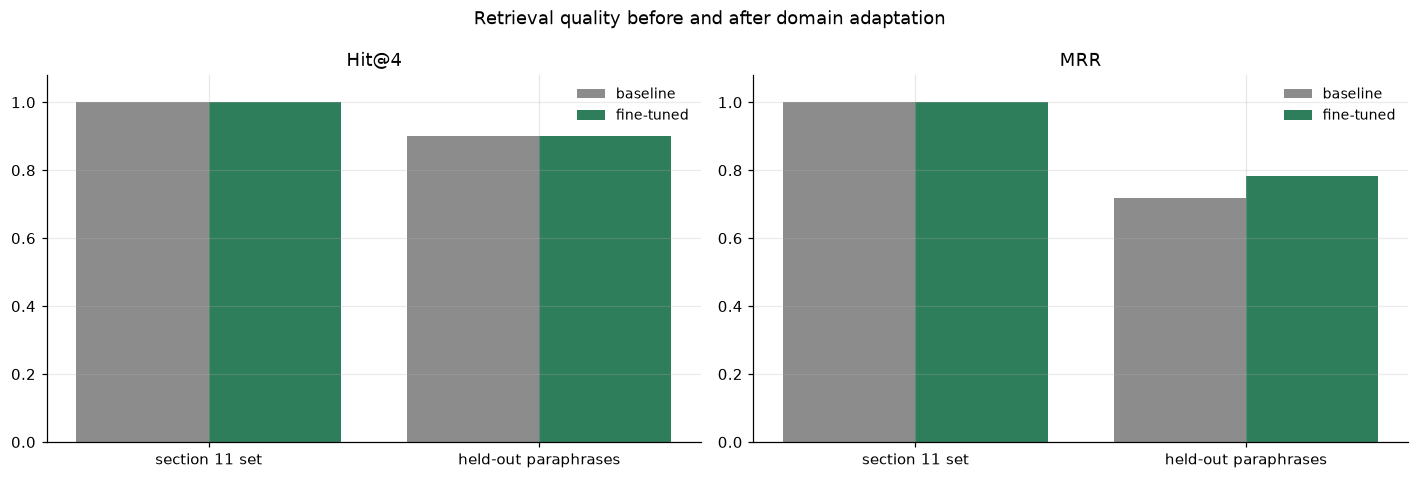

In [38]:
# ----------------------------------------------------------------------
# 12.5  Visualise before vs after
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
_sets = [f"section 11 set ({len(EVAL_SET)})", f"held-out paraphrases ({len(HARD_EVAL)})"]
_metrics = ["Hit@4", "MRR"]


def _vals(embedder, metric):
    return [comparison_df[(comparison_df.embedder == embedder) &
                          (comparison_df["evaluation set"] == s)][metric].iloc[0]
            for s in _sets]


for ax, metric in zip(axes, _metrics):
    x = np.arange(len(_sets))
    ax.bar(x - 0.2, _vals("baseline bge-small-en-v1.5", metric), 0.4,
           label="baseline", color="#8C8C8C")
    ax.bar(x + 0.2, _vals(f"fine-tuned ({FT_EPOCHS} epochs)", metric), 0.4,
           label="fine-tuned", color="#2E7D5B")
    ax.set_title(metric)
    ax.set_xticks(x)
    ax.set_xticklabels(["section 11 set", "held-out paraphrases"])
    ax.set_ylim(0, 1.08)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(frameon=False, fontsize=9)

fig.suptitle("Retrieval quality before and after domain adaptation", fontsize=12)
plt.tight_layout()
plt.show()

### How to read these numbers

The training run is seeded (`FT_SEED = 42`), so these figures are reproducible:
re-running this notebook reproduces them exactly. That was not true before the
seed was pinned — the shuffle alone moved the held-out `MRR` between `0.72` and
`0.78` across identical runs, which is precisely how a write-up ends up
disagreeing with its own output.

Four things are worth pulling out of the comparison above.

**1. The section 11 set is saturated, so it cannot improve — read it as a guard.**
`Hit@4` and `MRR` were both already `1.000` before training, and they stay at
`1.000` afterwards: no correct answer is lost out of twelve, and every question
still retrieves its section at rank 1. A saturated set cannot demonstrate a
gain — what it demonstrates is **no regression**, which matters just as much
when the change is deployed.

**2. The held-out paraphrases are where the gain appears.**
These ten colloquial questions share no wording with the documentation and were
never used for training. `MRR` rises from `0.717` to `0.783` — the correct
section moves up the ranking on questions phrased the way a real user would ask
them.

**3. Margin (correct minus strongest wrong) widens on both sets.**
`0.1486 → 0.1661` in-domain and `0.0259 → 0.0412` on the paraphrases. The margin
is the more sensitive instrument: it detects that the tuned model separates
right from wrong *more decisively*, even where the ordering does not change.
That robustness is what you want when real traffic is unlabelled.

**4. Four epochs, not ten.**
A separate sweep over the epoch count is what fixed `FT_EPOCHS = 4`. At 10 epochs
the paraphrase margin kept rising, but `Hit@4` on those same paraphrases *fell*
from `0.900` to `0.800`, and `MRR` on the training distribution degraded as well.
That is the classic signature of overfitting twenty pairs. On a corpus this small
the honest rule is: **stop when the held-out set stops improving, not when the
training loss stops falling.**

### Scope of the claim

The training questions never appear in either evaluation set, but they do target
the same 25 chunks — because domain adaptation, by definition, fits the corpus
you are going to retrieve from. The measured improvement therefore shows
**adaptation to this corpus**, not generalisation to unseen documents. With 25
chunks, splitting by *document* would leave too few items to measure anything;
on a production corpus that is the protocol to use.

### Using the tuned model

The tuned weights are written to `artifacts/finetuned-embedder/` and the rest of
this notebook keeps using the baseline, so the two can be compared. To serve with
the tuned model, point the configuration at it and rebuild the index — the
stored embeddings must always come from the same model that will encode queries:

```ini
LOCAL_EMBED_MODEL=artifacts/finetuned-embedder
```

```bash
rm -rf artifacts/vector_store   # mandatory: stale vectors are a silent failure
```

## 13. Conclusion

The notebook implements the complete RAG pipeline described in the project plan.
Every setting comes from `.env`:

| Setting | Default | Overridable |
|---|---|---|
| Endpoint | `https://api.openai.com/v1` | `OPENAI_BASE_URL` |
| Embedding backend | `api` (remote, 1536-d) | `EMBED_BACKEND`, `OPENAI_EMBED_MODEL`, `LOCAL_EMBED_MODEL` |
| Generation | `gpt-4o-mini`, temperature 0 | `OPENAI_CHAT_MODEL`, `OPENAI_TEMPERATURE` |
| Credential | — | `OPENAI_API_KEY` |

Generation is always remote, so there is deliberately **no offline mode**. A
previous revision could fall back to a local TF-IDF/LSA embedder *and* an
extractive generator, which made the notebook runnable with no credentials at all
— but it also meant the delivered artefact could silently differ from the
production system, using a statistical retriever where the real system uses a
neural one.

The optional **local embedding backend** is a different proposition, and worth
separating from that: it is a real neural model, it is selected explicitly by
`EMBED_BACKEND=local` rather than by accident, and its identity and dimension are
printed in §3.6. Nothing is implicit, and nothing degrades behind your back.
Where a fallback would hide a misconfiguration, section 3 fails fast with a
diagnosis instead.

What was delivered:

1. **Theory** — self-attention, the three RAG stages, cosine similarity, and a
   formal comparison of RAG against fine-tuning.
2. **Configuration** — `.env` loading, a fatal preflight that separates
   authentication failures from missing routes (and, in local mode, from a broken
   local install), and a component report.
3. **A real knowledge base** — 10 sections of IT help-desk documentation, parsed
   into section-tagged chunks.
4. **Chunking** — 500-character recursive splitting with 50-character overlap,
   performed per section so that chunks inherit citable metadata.
5. **Embeddings** — a pluggable embedding stage with two interchangeable
   backends: a remote `OpenAIEmbeddings` call, or a local
   `sentence-transformers` model running in-process. Both L2-normalise their
   output so that inner product equals cosine similarity, and the dimension is
   read at runtime rather than assumed.
6. **Vector search** — a FAISS `IndexFlatIP` (with a NumPy fallback), persisted to
   disk with its metadata.
7. **Agent logic** — a constrained prompt with explicit context markers, an LCEL
   chain, and a groundedness gate that abstains **before** the model is called.
8. **Testing** — in-domain questions answered with citations; out-of-domain
   questions refused and escalated.
9. **Evaluation** — Hit@k, MRR and rank distribution on a labelled set, plus a 2-D
   projection of the embedding space.
10. **Training** — a real, CPU-executed contrastive fine-tuning of the embedding
    model (§12): 20 paraphrase pairs, in-batch negatives, re-indexing with the
    tuned weights, and a before/after comparison over two evaluation sets.

### Known limitations

* The groundedness scorer is **lexical**, and it can veto a *correct* retrieval.
  Measured on this corpus: *"What does error E-2011 mean and how do I fix it?"*
  retrieves the answering chunk at rank 1 (cosine similarity 0.682) and is then
  refused anyway, because `mean` and `fix` never appear literally in the
  documentation while `means` does. Scoring content words without stemming
  penalises perfectly ordinary phrasing. Stemming before scoring, or an
  embedding-based gate, would be more robust.
* Retrieval is **single-turn**; there is no conversational query rewriting, so
  follow-ups such as "and what about the Mac client?" lose their antecedent.
* Multi-hop questions that require joining several sections are answered from the
  top-$k$ only; an agentic loop with several retrieval rounds would be needed.
* **Generation** is online-only: every run needs reachable credentials, so there
  is no fully air-gapped execution path. Embeddings can run locally, the
  generator cannot — which is what keeps `OPENAI_API_KEY` mandatory.
* The persisted index is tied to whichever embedding backend produced it.
  Changing `EMBED_BACKEND`, `OPENAI_EMBED_MODEL` or `LOCAL_EMBED_MODEL` after
  indexing silently corrupts retrieval — re-index.
* The tuned embedder of §12 is fitted on the same 25 chunks that it subsequently
  retrieves from, so the measured gain is **domain adaptation**, not
  generalisation to unseen documents. A production corpus would hold out whole
  documents for evaluation, and re-tune as it grows.
* The local backend fixes CPU inference cost, but its first run downloads the
  weights (roughly 130 MB for `bge-small-en-v1.5`, 2.3 GB for `bge-m3`) and it
  needs `torch` on the machine: about 400 MB installed, against zero for a
  pure-API setup.

### Next steps

* Add a re-ranker (cross-encoder) over the top-20 candidates before generation.
* Wrap the retriever as a tool and let the LLM decide *when* and *what* to search.
* Add conversation memory and query rewriting for multi-turn support.
* Log every `(question, retrieved context, answer, coverage)` quadruple. Those
  logs are the raw material for the next round of §12: real user phrasing, with
  the retrieved section acting as a weak label.
* Cache embeddings on disk, keyed by `(model, chunk hash)`, so re-runs during
  development do not re-bill the API.

In [39]:
# ----------------------------------------------------------------------
# 13.1  Final report and artefacts
# ----------------------------------------------------------------------
n_answered = len(batch_df) - int(batch_df.abstained.sum())
n_refused = int(batch_df.abstained.sum())

print("=" * 74)
print("TECHNICAL SUPPORT AI AGENT - FINAL REPORT")
print("=" * 74)
print(f"Knowledge base        : {KB_PATH.name} "
      f"({len(raw_text):,} chars, {len(sections)} sections)")
print(f"Chunks indexed        : {len(chunks)}  (chunk_size={CHUNK_SIZE}, "
      f"overlap={CHUNK_OVERLAP})")
print(f"Embedding backend     : {EMBED_BACKEND}")
print(f"Vector store          : {vector_store.name}  ({len(vector_store)} vectors)")
print(f"Generator backend     : {GENERATOR_BACKEND}")
print(f"Chain                 : {CHAIN_IMPL}")
print(f"Retrieval Hit@{TOP_K}       : {hit_at_k:.3f}   (baseline embedder)")
print(f"Retrieval MRR         : {mrr:.3f}   (baseline embedder)")

_held = comparison_df["evaluation set"].str.startswith("held-out")
_base_row = comparison_df[(comparison_df.embedder.str.startswith("baseline")) & _held].iloc[0]
_tuned_row = comparison_df[(comparison_df.embedder.str.startswith("fine-tuned")) & _held].iloc[0]
print(f"Fine-tuned embedder   : held-out paraphrases, MRR "
      f"{_base_row['MRR']:.3f} -> {_tuned_row['MRR']:.3f}, "
      f"margin {_base_row['margin']:.4f} -> {_tuned_row['margin']:.4f}")
print(f"Labelled eval set     : {len(eval_df)} questions, "
      f"{int(eval_df.hit.sum())} retrieved correctly")
print(f"Batch run             : {n_answered}/{len(batch_df)} answered, "
      f"{n_refused} abstained")
print("=" * 74)

print("\nArtefacts written to ./artifacts :")
for path in sorted(DATA_DIR.rglob("*")):
    if path.is_file():
        print(f"  {path.relative_to(BASE_DIR)}  ({path.stat().st_size:,} bytes)")

TECHNICAL SUPPORT AI AGENT - FINAL REPORT
Knowledge base        : tech_support.txt (8,732 chars, 10 sections)
Chunks indexed        : 25  (chunk_size=500, overlap=50)
Embedding backend     : BAAI/bge-m3 (local, 1024-d)
Vector store          : FaissVectorStore (IndexFlatIP, cosine)  (25 vectors)
Generator backend     : claude-sonnet-4-5 @ https://modelgate.app/v1 (temperature=0.0)
Chain                 : LangChain LCEL (prompt | llm | StrOutputParser)
Retrieval Hit@4       : 1.000   (baseline embedder)
Retrieval MRR         : 1.000   (baseline embedder)
Fine-tuned embedder   : held-out paraphrases, MRR 0.717 -> 0.783, margin 0.0259 -> 0.0412
Labelled eval set     : 12 questions, 12 retrieved correctly
Batch run             : 7/9 answered, 2 abstained

Artefacts written to ./artifacts :
  artifacts/01_corpus_overview.png  (70,067 bytes)
  artifacts/02_chunking.png  (73,702 bytes)
  artifacts/03_retrieval_scores.png  (35,355 bytes)
  artifacts/04_retrieval_evaluation.png  (32,806 bytes)
 

---

### References

1. Vaswani et al., *Attention Is All You Need*, NeurIPS 2017.
2. Lewis et al., *Retrieval-Augmented Generation for Knowledge-Intensive NLP
   Tasks*, NeurIPS 2020.
3. Karpukhin et al., *Dense Passage Retrieval for Open-Domain Question
   Answering*, EMNLP 2020.
4. Johnson, Douze & Jégou, *Billion-scale Similarity Search with GPUs* (FAISS),
   IEEE Transactions on Big Data, 2019.
5. Neelakantan et al., *Text and Code Embeddings by Contrastive Pre-Training*,
   OpenAI, 2022.
6. Hu et al., *LoRA: Low-Rank Adaptation of Large Language Models*, ICLR 2022.
7. LangChain documentation — *LCEL* and *Retrieval* guides.
8. OpenAI API reference — *Embeddings* and *Chat Completions*.